# TP2 - Predicción de Género Musical (Spotify)
**Tecnología Digital VI - Inteligencia Artificial**

Maria Victoria Bullrich, Candela Shaiel Guinzburg y Oliverio **AGREGAR APELLIDO**

## **Introducción y Objetivo**

Este notebook presenta un análisis exploratorio del dataset de Spotify y la implementación de dos modelos de clasificación multiclase (Árbol de Decisión y Random Forest), incluyendo el preprocesamiento y la ingeniería de features sin *data leakage*, una búsqueda de hiperparámetros optimizando F1-macro, y un proceso de Model Selection basado en cross-validation. El objetivo es desarrollar un modelo que pueda predecir el género musical de una canción a partir de sus features acústicas y de popularidad, y discutir las implicancias de negocio de optimizar distintas métricas (F1-macro promedio vs. MAP@3) para diferentes aplicaciones.

## **Instrucciones de Uso**

Este notebook se ejecuta secuencialmente de principio a fin, asumiendo que los archivos `train.csv` y `test.csv` se encuentran descomprimidos en un subdirectorio llamado `prediccion-de-generos-musicales-2-s-2026`.

Las dependencias necesarias son:
- numpy
- pandas
- matplotlib
- seaborn
- scikit-learn

## **Notas, Aclaraciones y Replicabilidad**

Es importante mencionar que, incluso fijando la semilla aleatoria (`random_state`) en todos los pasos del pipeline, es posible observar pequeñas diferencias en los resultados de una corrida a otra, especialmente en métricas muy específicas como la cantidad exacta de hojas o la profundidad del árbol de decisión. Esto se debe a sutiles efectos de interacción entre el algoritmo y los datos. Estos efectos no suelen afectar significativamente a las métricas globales (accuracy, F1-score promediado sobre varios folds), pero sí pueden manifestarse en características puntuales de cada árbol. Por ende, pequeñas diferencias en los números reportados son esperables y no alteran las conclusiones generales.

# **Análisis Exploratorio de Datos (EDA)**
## Estructura y calidad del dataset

Antes de explorar las variables, revisamos la estructura general del dataset, la presencia de valores duplicados y de valores nulos.

In [210]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [211]:
df = pd.read_csv('prediccion-de-generos-musicales-2-s-2026/train.csv')
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,rock,2423


In [212]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4200 non-null   int64  
 1   duration_ms       4200 non-null   int64  
 2   explicit          4200 non-null   bool   
 3   danceability      4200 non-null   float64
 4   energy            4200 non-null   float64
 5   key               4200 non-null   int64  
 6   loudness          4200 non-null   float64
 7   mode              4200 non-null   int64  
 8   speechiness       4200 non-null   float64
 9   acousticness      4200 non-null   float64
 10  instrumentalness  4200 non-null   float64
 11  liveness          4200 non-null   float64
 12  valence           4200 non-null   float64
 13  tempo             4200 non-null   float64
 14  time_signature    4200 non-null   int64  
 15  Expected          4200 non-null   str    
 16  Id                4200 non-null   int64  
dtypes: boo

In [213]:
print("Filas duplicadas:", df.duplicated().sum())
print("Valores nulos por columna:")
print(df.isnull().sum())

Filas duplicadas: 0
Valores nulos por columna:
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
Expected            0
Id                  0
dtype: int64


In [214]:
def detectar_valores_nulos_extendido(df, tokens_nulos_texto=None, valores_centinela_numericos=None):
    """
    Búsqueda extendida de valores "nulos" más allá de lo que detecta df.isnull():
    - NaN/None reales
    - infinitos (np.inf, -np.inf)
    - strings que representan "nulo" disfrazado( "null", "none",
      "nan", "na", "n/a", "-", "?", "unknown", "missing", "s/d", cadena vacía, etc)."""
    

    tokens_default = ['null', 'none', 'nan', 'na', 'n/a', 'n.a.', '-', '--', '?', '??',
                       'unknown', 'undefined', 'missing', 'not available', 's/d',
                       'sin dato', '#n/a', '#value!', 'nil', '']
    tokens = set(t.lower() for t in (tokens_default + (tokens_nulos_texto or [])))

    filas = []
    for col in df.columns:
        serie = df[col]
        nulos_reales = serie.isnull().sum()
        infinitos = 0
        menos_uno = 0
        texto_disfrazado = 0

        if pd.api.types.is_numeric_dtype(serie):
            infinitos = np.isinf(serie).sum()
            menos_uno = (serie == -1).sum()
        else:
            texto_disfrazado = serie.astype(str).str.strip().str.lower().isin(tokens).sum()

        filas.append({
            'columna': col,
            'nulos_reales (NaN/None)': nulos_reales,
            'infinitos (inf/-inf)': infinitos,
            'texto_disfrazado_de_nulo': texto_disfrazado,
            'valor_centinela (-1)': menos_uno,
        })

    resumen = pd.DataFrame(filas).set_index('columna')
    resumen['total_a_revisar'] = resumen.sum(axis=1)
    return resumen.sort_values('total_a_revisar', ascending=False)

print("Resumen extendido de valores nulos:")
print(detectar_valores_nulos_extendido(df))

Resumen extendido de valores nulos:
                  nulos_reales (NaN/None)  infinitos (inf/-inf)  \
columna                                                           
popularity                              0                     0   
duration_ms                             0                     0   
explicit                                0                     0   
danceability                            0                     0   
energy                                  0                     0   
key                                     0                     0   
loudness                                0                     0   
mode                                    0                     0   
speechiness                             0                     0   
acousticness                            0                     0   
instrumentalness                        0                     0   
liveness                                0                     0   
valence                   

No se encontraron valores nulos en el dataset, tampoco valores duplicados. Aunque debemos ser mas exaustivos en la busqueda de valores duplicados, ya que dentro de las variables se incluye la columna `Id`, que es un identificador único por fila. Por eso nunca se puede encontrar duplicados mientras `Id` esté presente, así que el resultado (0) no es evidencia real de ausencia de duplicados. Por eso volveremos a analizar los datos duplicados al eliminarle esta columna. 

Este analisis es correcta ya que La consigna del TP advierte que el dataset es un derivado de uno más grande de Spotify, y una misma canción podría aparecer más de una vez bajo un `Id` distinto (por ejemplo, publicada en un álbum y también en un recopilatorio, o una versión remasterizada). 

In [215]:
# Buscamos duplicados ignorando el Id sintético.
feature_cols_no_id = [c for c in df.columns if c not in ['Id']]

exact_dups_mask = df.duplicated(subset=feature_cols_no_id, keep=False)
print("Filas involucradas en duplicados EXACTOS (sin contar Id):", exact_dups_mask.sum())

if exact_dups_mask.sum() > 0:
    display(df.loc[exact_dups_mask].sort_values(feature_cols_no_id).head(20))

Filas involucradas en duplicados EXACTOS (sin contar Id): 908


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
1565,0,42440,True,0.409,0.990,11,-2.084,1,0.1150,0.0200,0.000000,0.5130,0.962,172.715,4,rock,3942
4031,0,42440,True,0.409,0.990,11,-2.084,1,0.1150,0.0200,0.000000,0.5130,0.962,172.715,4,rock,4481
676,0,68760,False,0.684,0.437,9,-10.522,1,0.0491,0.7420,0.000016,0.2240,0.964,107.607,4,jazz,3806
1247,0,68760,False,0.684,0.437,9,-10.522,1,0.0491,0.7420,0.000016,0.2240,0.964,107.607,4,jazz,2337
1884,0,68760,False,0.684,0.437,9,-10.522,1,0.0491,0.7420,0.000016,0.2240,0.964,107.607,4,jazz,267
2849,0,68760,False,0.684,0.437,9,-10.522,1,0.0491,0.7420,0.000016,0.2240,0.964,107.607,4,jazz,5356
4180,0,68760,False,0.684,0.437,9,-10.522,1,0.0491,0.7420,0.000016,0.2240,0.964,107.607,4,jazz,3967
699,0,69000,False,0.635,0.393,9,-10.889,1,0.0394,0.6520,0.000000,0.0845,0.970,107.172,4,jazz,80
741,0,69000,False,0.635,0.393,9,-10.889,1,0.0394,0.6520,0.000000,0.0845,0.970,107.172,4,jazz,1311
1143,0,69000,False,0.635,0.393,9,-10.889,1,0.0394,0.6520,0.000000,0.0845,0.970,107.172,4,jazz,4084


Al eliminar la columna `id` si aparecen datos duplicados, lo más razonable es eliminarlos (quedarse con una sola copia) antes de armar el split train/validación. Dejarlos duplicados le da a esa canción el doble de peso en el entrenamiento y, peor, si una copia termina en `train` y la otra en el 20% de `X_val`, el modelo estaría siendo "evaluado" con una canción que ya vio en entrenamiento.

El chequeo encontró **908 filas involucradas en duplicados exactos**, correspondientes a solo **245 canciones únicas** repetidas bajo distintos `Id` (algunas hasta 27 veces). Por eso procedemos a eliminar duplicados (quedándonos con una copia de cada canción) el dataset pasa de 4200 a **3537 filas**(Eliminando más del 15% del dataset)


expected_ranges = {
    'popularity': (0, 100),
    'danceability': (0, 1), 'energy': (0, 1), 'speechiness': (0, 1),
    'acousticness': (0, 1), 'instrumentalness': (0, 1), 'liveness': (0, 1),
    'valence': (0, 1),
    'key': (0, 11),
    'duration_ms': (0, np.inf),
    'tempo': (0, np.inf),
}

for col, (low, high) in expected_ranges.items():
    out_of_range = df[(df[col] < low) | (df[col] > high)]
    if len(out_of_range) > 0:
        print(f"⚠️  {col}: {len(out_of_range)} filas fuera del rango esperado [{low}, {high}]")
    else:
        print(f"✅ {col}: todos los valores dentro de [{low}, {high}]")

Como algunas variables de Spotify tienen un rango documentado (0 a 1 para los "índices" como `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`; 0 a 100 para `popularity`; enteros 0-11 para `key`). Un valor fuera de ese rango sería un error de carga de datos, no un outlier estadístico legítimo. por eso lo analisamos para seguir en el analisis y corroborar que todos los datos con los que se entrena el modelo sen correctos. 
No se encontro ningun valor fuera de rango, por lo que procedemos unicamente a eliminar las variables duplicadas


In [216]:
# Eliminamos duplicados exactos,

filas_antes = df.shape[0]
df = df.drop_duplicates(subset=feature_cols_no_id, keep='first').reset_index(drop=True)
print(f"Filas antes de deduplicar: {filas_antes}")
print(f"Filas después de deduplicar: {df.shape[0]}")
print(f"Filas eliminadas: {filas_antes - df.shape[0]}")

Filas antes de deduplicar: 4200
Filas después de deduplicar: 3537
Filas eliminadas: 663


Verificamos si el dataset está balanceado o no, para esto vamos a ver la cantidad de canciones por género

In [217]:

df['Expected'].value_counts()

Expected
electronic    696
acoustic      685
classical     631
hip-hop       594
rock          527
jazz          404
Name: count, dtype: int64

 Luego de eliminar los datos duplicados quedaron las siguientes cantidad de canciones por genero,`electronic` (696), `acoustic` (685), `classical` (631), `hip-hop` (594), `rock` (527) y `jazz` (404),. Lo cual muestra que el dataset no esta balanceando, habiendo una diferenciade aproximadamente de 1.7x entre la clase más grande y la más chicade. Este dato lo tendremos que tener en cuenta mas adelante.

## Distribución de variables acústicas por género

Analizamos la distribución de las variables más relevantes para diferenciar géneros musicales, comparando su comportamiento entre las 6 categorías. Miramos la mediana de cada feature acústica agrupada por género. Esto nos da una primera lectura cuantitativa de qué variables muestran más dispersión entre clases (candidatas a ser buenas discriminantes)

In [218]:
# Paleta de colores fija por género, reutilizada en todos los gráficos del EDA

GENRE_ORDER = sorted(df['Expected'].unique())
GENRE_PALETTE = dict(zip(GENRE_ORDER, sns.color_palette('tab10', n_colors=len(GENRE_ORDER))))
# aplicamos los mismos colores a lo largo de todo el notebook para cada género
GENRE_PALETTE = dict(zip(GENRE_ORDER, sns.color_palette('tab10', n_colors=len(GENRE_ORDER))))
acoustic_cols = ['popularity','danceability','energy','loudness','speechiness',
                 'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']

medianas_por_genero = df.groupby('Expected')[acoustic_cols].median()
medianas_por_genero

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
Expected,,,,,,,,,,,
acoustic,48.0,0.5480,0.3890,-9.159,0.03520,0.7020,0.000003,0.1150,0.3710,116.0290,212893.0
classical,4.0,0.3810,0.1420,-20.443,0.04260,0.9730,0.851000,0.1190,0.3470,103.7670,187746.0
electronic,47.0,0.6635,0.7065,-6.744,0.04880,0.0639,0.010600,0.1275,0.3630,123.0015,214551.5
hip-hop,59.0,0.7325,0.7050,-5.886,0.09405,0.1375,0.000000,0.1335,0.5445,108.9900,205475.0
jazz,1.0,0.5225,0.3470,-10.819,0.03880,0.7735,0.000019,0.1250,0.4530,112.6755,194839.5
rock,1.0,0.5520,0.7310,-6.091,0.03920,0.0724,0.000012,0.1160,0.5280,123.2230,220413.0


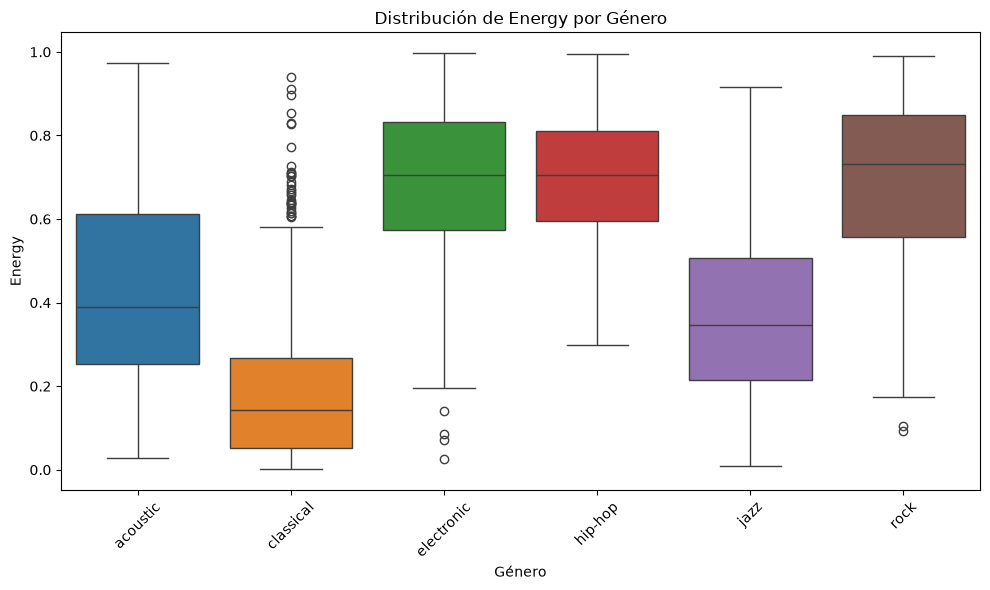

In [219]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='energy', order=GENRE_ORDER, palette=GENRE_PALETTE, hue='Expected', legend=False)
plt.xticks(rotation=45)
plt.title('Distribución de Energy por Género')
plt.xlabel('Género')
plt.ylabel('Energy')
plt.tight_layout()
plt.show()

El boxplot de ``energy`` muestra diferencias claras entre géneros. ``Classical`` se distingue notoriamente del resto, con una mediana muy baja (cerca de 0.15) y una caja angosta, lo que indica que casi todas las canciones clásicas comparten niveles de energía similares y bajos. En el otro extremo, ``electronic``, ``hip-hop`` y ``rock`` presentan medianas altas y muy parecidas entre sí (alrededor de 0.70), por lo que esta variable sola no permite diferenciarlos. ``Jazz`` y ``acoustic`` quedan en un rango intermedio, con mayor dispersión. Se observan además varios outliers, especialmente en ``classical``: al ser un género tan homogéneo en baja energía, cualquier canción con valores algo más altos queda marcada como atípica, aunque en términos absolutos no sean valores extraños. No se aplicó ningún tratamiento sobre estos outliers, dado que los modelos utilizados (árboles de decisión y Random Forest) son robustos a su presencia.

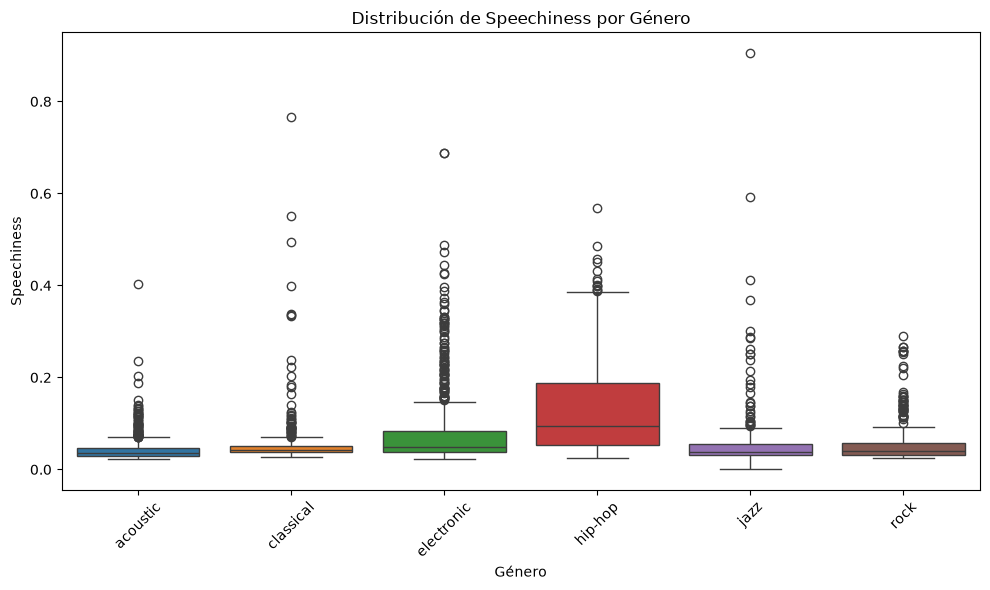

In [220]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='speechiness', order=GENRE_ORDER, palette=GENRE_PALETTE, hue='Expected', legend=False)
plt.xticks(rotation=45)
plt.title('Distribución de Speechiness por Género')
plt.xlabel('Género')
plt.ylabel('Speechiness')
plt.tight_layout()
plt.show()

El boxplot de ``speechiness`` muestra que la gran mayoría de las canciones, en todos los géneros, tienen valores bajos (cercanos a 0), ya que esta variable mide la presencia de habla pura y la mayor parte de la música no consiste en eso. La excepción es ``hip-hop``, que se destaca con una mediana notablemente más alta (≈0.10) y una caja más ancha, coherente con la mayor presencia de voz hablada característica del género. Se observan numerosos outliers en los seis géneros: al ser el rango típico tan angosto para la mayoría, cualquier canción con más contenido hablado de lo usual (una intro hablada, un sample de voz) queda marcada como atípica, incluso en géneros donde eso es poco frecuente. No se aplicó ningún tratamiento sobre estos valores, dado que los modelos utilizados son robustos a la presencia de outliers.

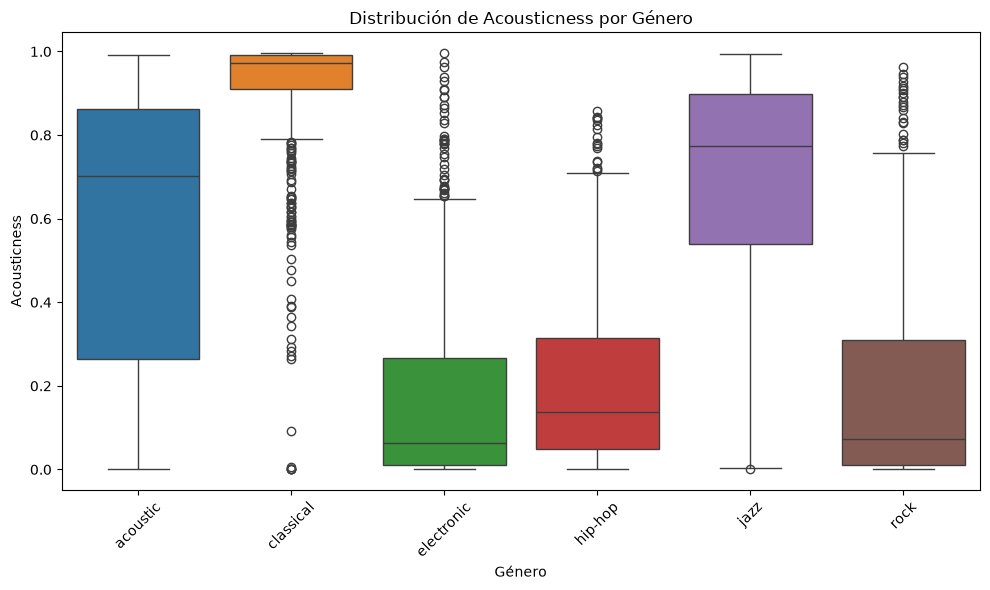

In [221]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='acousticness', order=GENRE_ORDER, palette=GENRE_PALETTE, hue='Expected', legend=False)
plt.xticks(rotation=45)
plt.title('Distribución de Acousticness por Género')
plt.xlabel('Género')
plt.ylabel('Acousticness')
plt.tight_layout()
plt.show()

El boxplot de ``acousticness`` separa claramente dos grupos: por un lado ``jazz`` y ``classical``, con medianas altas (0.78 y 0.97 respectivamente); por otro lado, ``electronic``, ``hip-hop`` y ``rock``, con medianas bajas (entre 0.06 y 0.13). El género ``acoustic`` es la excepción: presenta una caja mucho más ancha que el resto (de 0.27 a 0.86), lo que indica una gran variabilidad interna y sugiere que esta variable por sí sola no lo caracteriza bien. Los outliers siguen un patrón coherente: en los géneros de acousticness alta (``jazz``, ``classical``) aparecen hacia abajo, correspondiendo a canciones con sonido más electrónico de lo típico para ese estilo; en los géneros de acousticness baja (``electronic``, ``hip-hop``, ``rock``) aparecen hacia arriba, canciones más "acústicas" de lo esperado. No se aplicó ningún tratamiento sobre estos valores por las mismas razones mencionadas anteriormente.

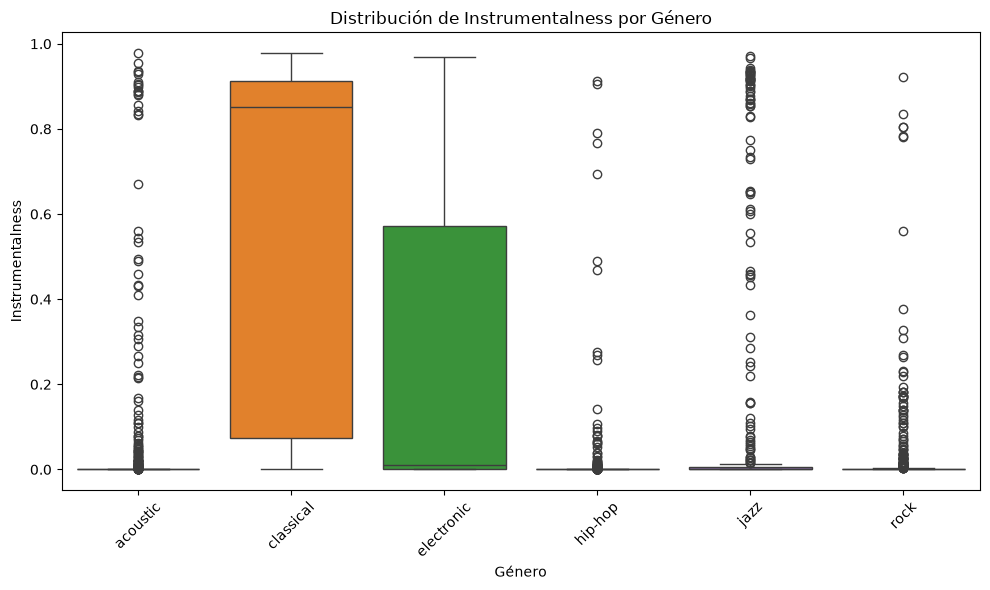

In [222]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='instrumentalness', order=GENRE_ORDER, palette=GENRE_PALETTE, hue='Expected', legend=False)
plt.xticks(rotation=45)
plt.title('Distribución de Instrumentalness por Género')
plt.xlabel('Género')
plt.ylabel('Instrumentalness')
plt.tight_layout()
plt.show()

El boxplot de `instrumentalness` distingue con claridad a `classical`, con una mediana alta (≈0.86) y una caja ancha que va de 0.12 a 0.92, coherente con que la mayoría de la música clásica es instrumental. En el resto de los géneros (`jazz`, `hip-hop`, `acoustic`, `rock`) la mediana queda pegada a 0, con la caja prácticamente colapsada y una gran cantidad de outliers hacia arriba. Esto tiene sentido, ya que en géneros predominantemente vocales lo esperable es un valor bajo, y los outliers representan los temas puramente instrumentales dentro de cada uno. `Electronic` es un caso intermedio: también tiene mediana baja, pero su caja es notablemente más ancha que la de los demás (llega hasta 0.57), reflejando que una porción más grande de canciones electrónicas son instrumentales. En conclusión, esta variable separa muy bien a `classical` del resto, pero no aporta demasiado para diferenciar entre los otros cinco géneros, que quedan todos concentrados en valores cercanos a cero.

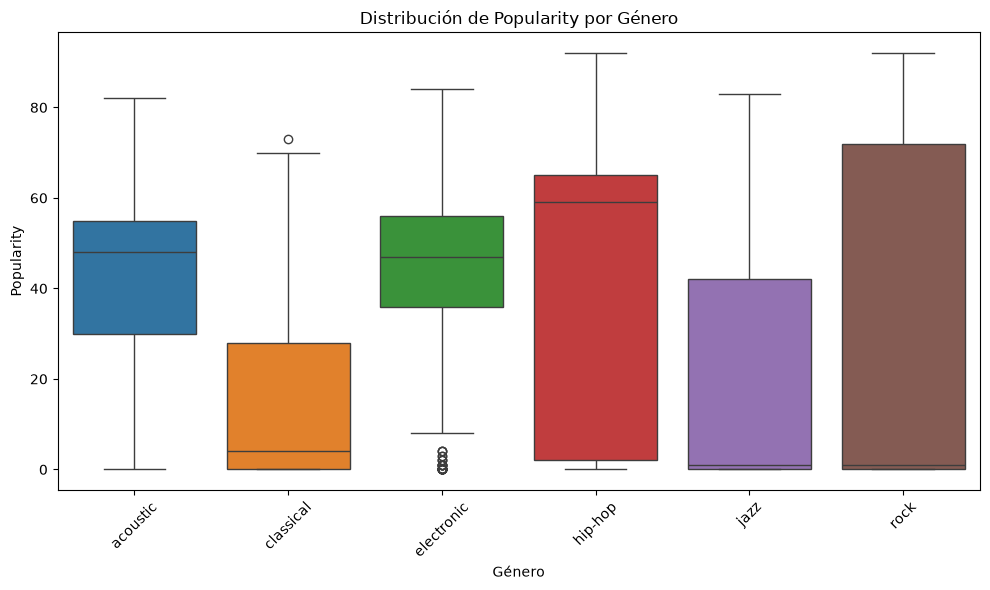

In [223]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Expected', y='popularity', order=GENRE_ORDER, palette=GENRE_PALETTE, hue='Expected', legend=False)
plt.xticks(rotation=45)
plt.title('Distribución de Popularity por Género')
plt.xlabel('Género')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

El boxplot de `popularity` muestra diferencias entre géneros, aunque con un patrón llamativo que conviene señalar. En `jazz` y `rock` la mediana es exactamente 0, es decir que al menos la mitad de las canciones de esos géneros tienen popularidad nula, y algo similar ocurre en `hip-hop`, donde el primer cuartil también toca 0 pese a tener una mediana alta (58). Esto no parece un patrón puramente musical, sino más bien un artefacto de cómo Spotify calcula esta métrica (posiblemente relacionado a la actividad reciente de reproducciones), por lo que lo tomamos como una observación a tener en cuenta más que como una conclusión definitiva, ya que no tenemos forma de confirmarlo sin acceso a la documentación oficial de la métrica. Dejando de lado ese efecto, se nota una tendencia clara: `hip-hop`, `acoustic` y `electronic` presentan medianas o cajas superiores más altas que `classical` y `jazz`, lo que sugiere que sí existen diferencias reales de popularidad entre géneros, y que esta variable podría aportar información valiosa para diferenciar géneros más allá de las características puramente acústicas.

## Separación multivariada: ¿cuánto se solapan los géneros en conjunto?

Los boxplots anteriores muestran una variable a la vez. Para tener una idea de cómo se separan los géneros cuando se combinan varias variables acústicas a la vez, proyectamos el dataset a 2 dimensiones con PCA 

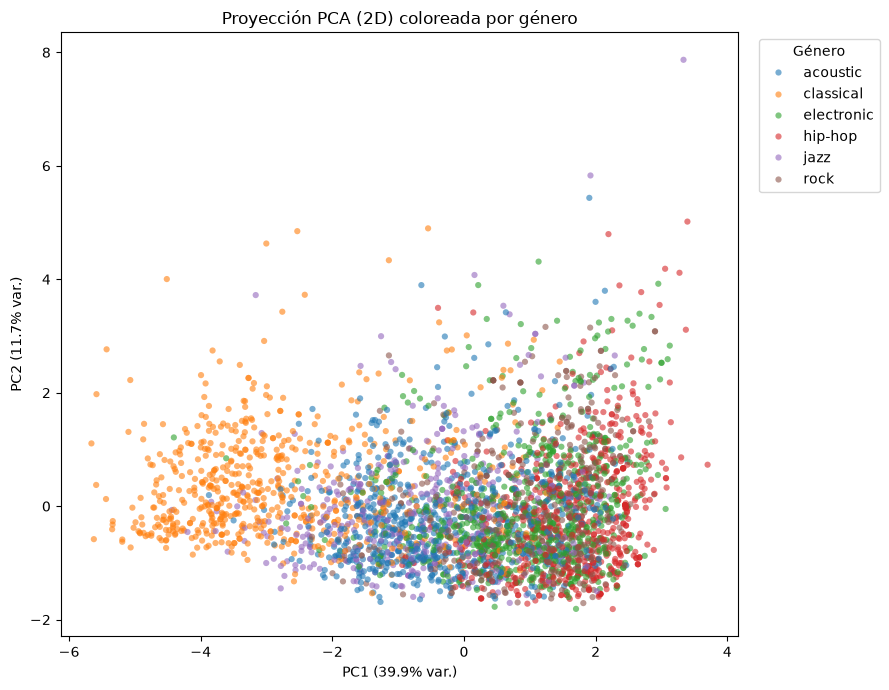

In [224]:
num_cols_eda = ['danceability','energy','loudness','speechiness','acousticness',
                'instrumentalness','liveness','valence','tempo']

X_eda = (df[num_cols_eda] - df[num_cols_eda].mean()) / df[num_cols_eda].std()
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_eda)

plt.figure(figsize=(9,7))
sns.scatterplot(x=pca_coords[:,0], y=pca_coords[:,1], hue=df['Expected'],
                hue_order=GENRE_ORDER, palette=GENRE_PALETTE, alpha=0.6, s=20, edgecolor='none')
plt.title('Proyección PCA (2D) coloreada por género')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)')
plt.legend(title='Género', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

La proyección PCA confirma lo que veníamos observando variable por variable: `classical` forma un cluster claramente separado del resto (consistente con sus valores extremos de `energy`, `acousticness` e `instrumentalness`), mientras que `electronic`, `hip-hop` y `rock` aparecen fuertemente solapados entre sí en este plano de 2 componentes. `Jazz` y `acoustic` quedan en zonas intermedias, con overlap parcial con casi todos los demás grupos. Esto es información clave de cara al modelado: **ningún modelo lineal simple ni una regla basada en 1-2 variables va a resolver bien el problema**; se necesita un modelo capaz de capturar interacciones no lineales entre variables (como los árboles/ensambles que usamos), y el error del modelo va a concentrarse, previsiblemente, en el trío `electronic`/`hip-hop`/`rock` y en `jazz` frente a `acoustic`.

## Correlación y asimetría entre variables numéricas

Como complemento al análisis variable por variable, estudiamos las relaciones entre todas las features numéricas para detectar posible redundancia de información. A su vez medimos la asimetría de cada una para decidir qué transformaciones aplicar en el preprocesamiento.

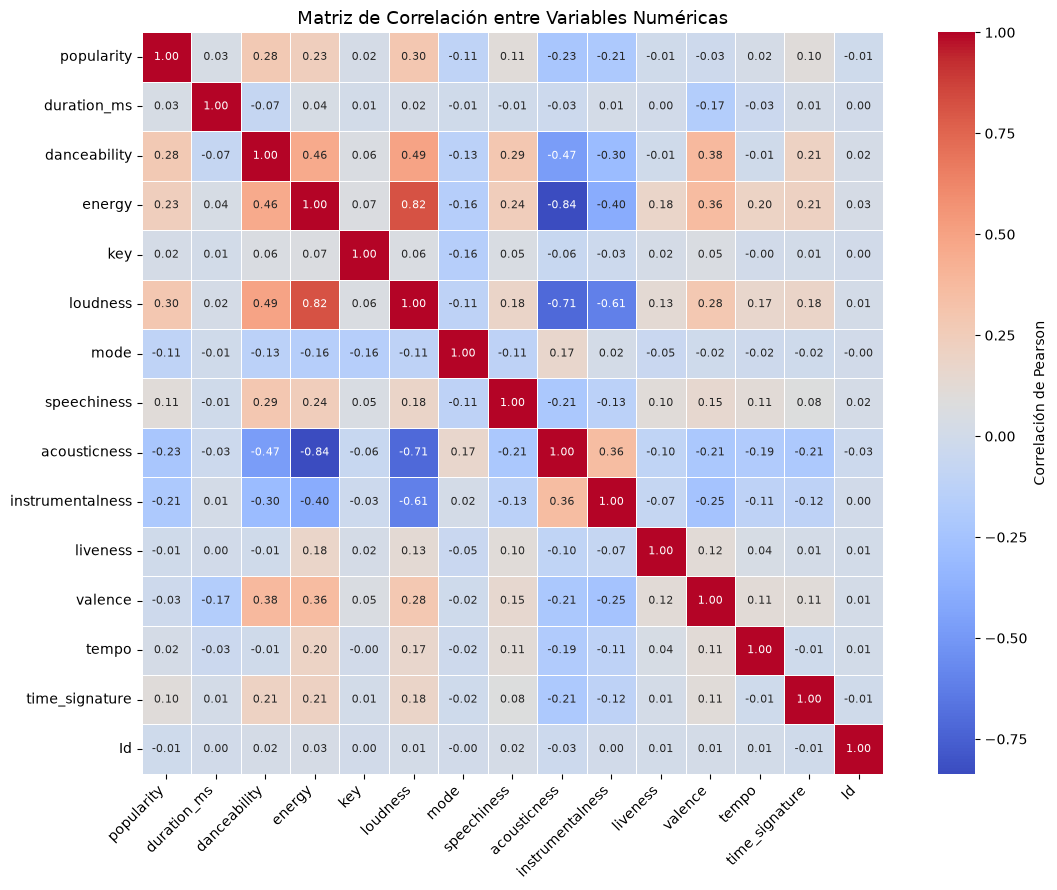

In [225]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size': 8}, cbar_kws={'label': 'Correlación de Pearson'},
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Como complemento, calculamos la matriz de correlación entre todas las variables numéricas. Se observan correlaciones fuertes entre algunas features, como ``energy`` y ``acousticness`` (-0.84) o ``energy`` y ``loudness`` (0.82), lo que indica cierta redundancia de información entre ellas. Esto es relevante a tener en cuenta especialmente si en algún momento se probara un modelo lineal, donde la correlación entre variables puede afectar la interpretación de los coeficientes. Como explicamos anteriormente, no utilizaremos modelos lineales, por lo que la redundancia es menos critica , pero la tenemos en cuenta al diseñar las features de interacción (para no simplemente duplicar información que el modelo ya puede reconstruir).

In [226]:
all_numeric_cols = ['popularity','danceability','energy','loudness','speechiness',
                     'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']

skew_values = df[all_numeric_cols].skew().sort_values(ascending=False)
skew_values

duration_ms         6.089501
speechiness         3.563141
liveness            2.469338
instrumentalness    1.482973
tempo               0.418164
valence             0.211900
acousticness        0.190287
popularity          0.004923
energy             -0.204656
danceability       -0.319271
loudness           -1.602825
dtype: float64

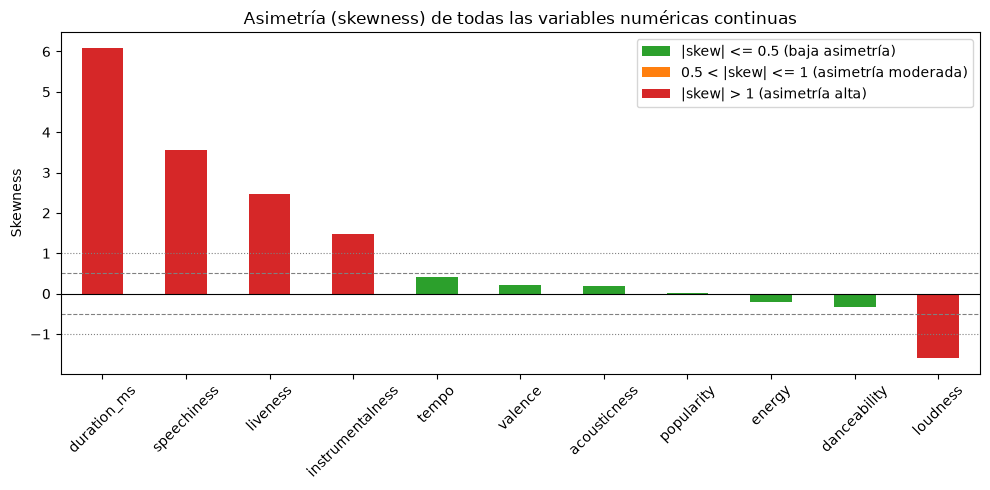

In [227]:
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#d62728' if abs(v) > 1 else ('#ff7f0e' if abs(v) > 0.5 else '#2ca02c') for v in skew_values]
skew_values.plot(kind='bar', color=colors, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(-0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(1, color='gray', linestyle=':', linewidth=0.8)
ax.axhline(-1, color='gray', linestyle=':', linewidth=0.8)
ax.set_title('Asimetría (skewness) de todas las variables numéricas continuas')
ax.set_ylabel('Skewness')
plt.xticks(rotation=45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='|skew| <= 0.5 (baja asimetría)'),
    Patch(facecolor='#ff7f0e', label='0.5 < |skew| <= 1 (asimetría moderada)'),
    Patch(facecolor='#d62728', label='|skew| > 1 (asimetría alta)')
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

Al calcular el skewness sobre las 11 variables numéricas continuas, `duration_ms` (6.00), `speechiness` (4.09), `liveness` (2.44) e `instrumentalness` (1.61) muestran una asimetría muy alta. `Loudness` (-1.58) también supera el umbral de sesgo fuerte, pero en sentido opuesto, una cola larga hacia valores muy negativos (canciones inusualmente silenciosas).


### Histogramas de todas las variables numéricas continuas
Como solo graficammos boxplots de 5 variables (`energy`, `speechiness`, `acousticness`, `instrumentalness`, `popularity`). Decidimos agregar Un panel de histogramas para las 11 variables numéricas continuas (incluyendo las que no se graficaron individualmente: `duration_ms`, `loudness`, `danceability`, `valence`, `tempo`, `liveness`) muestra la forma completa de cada distribución.

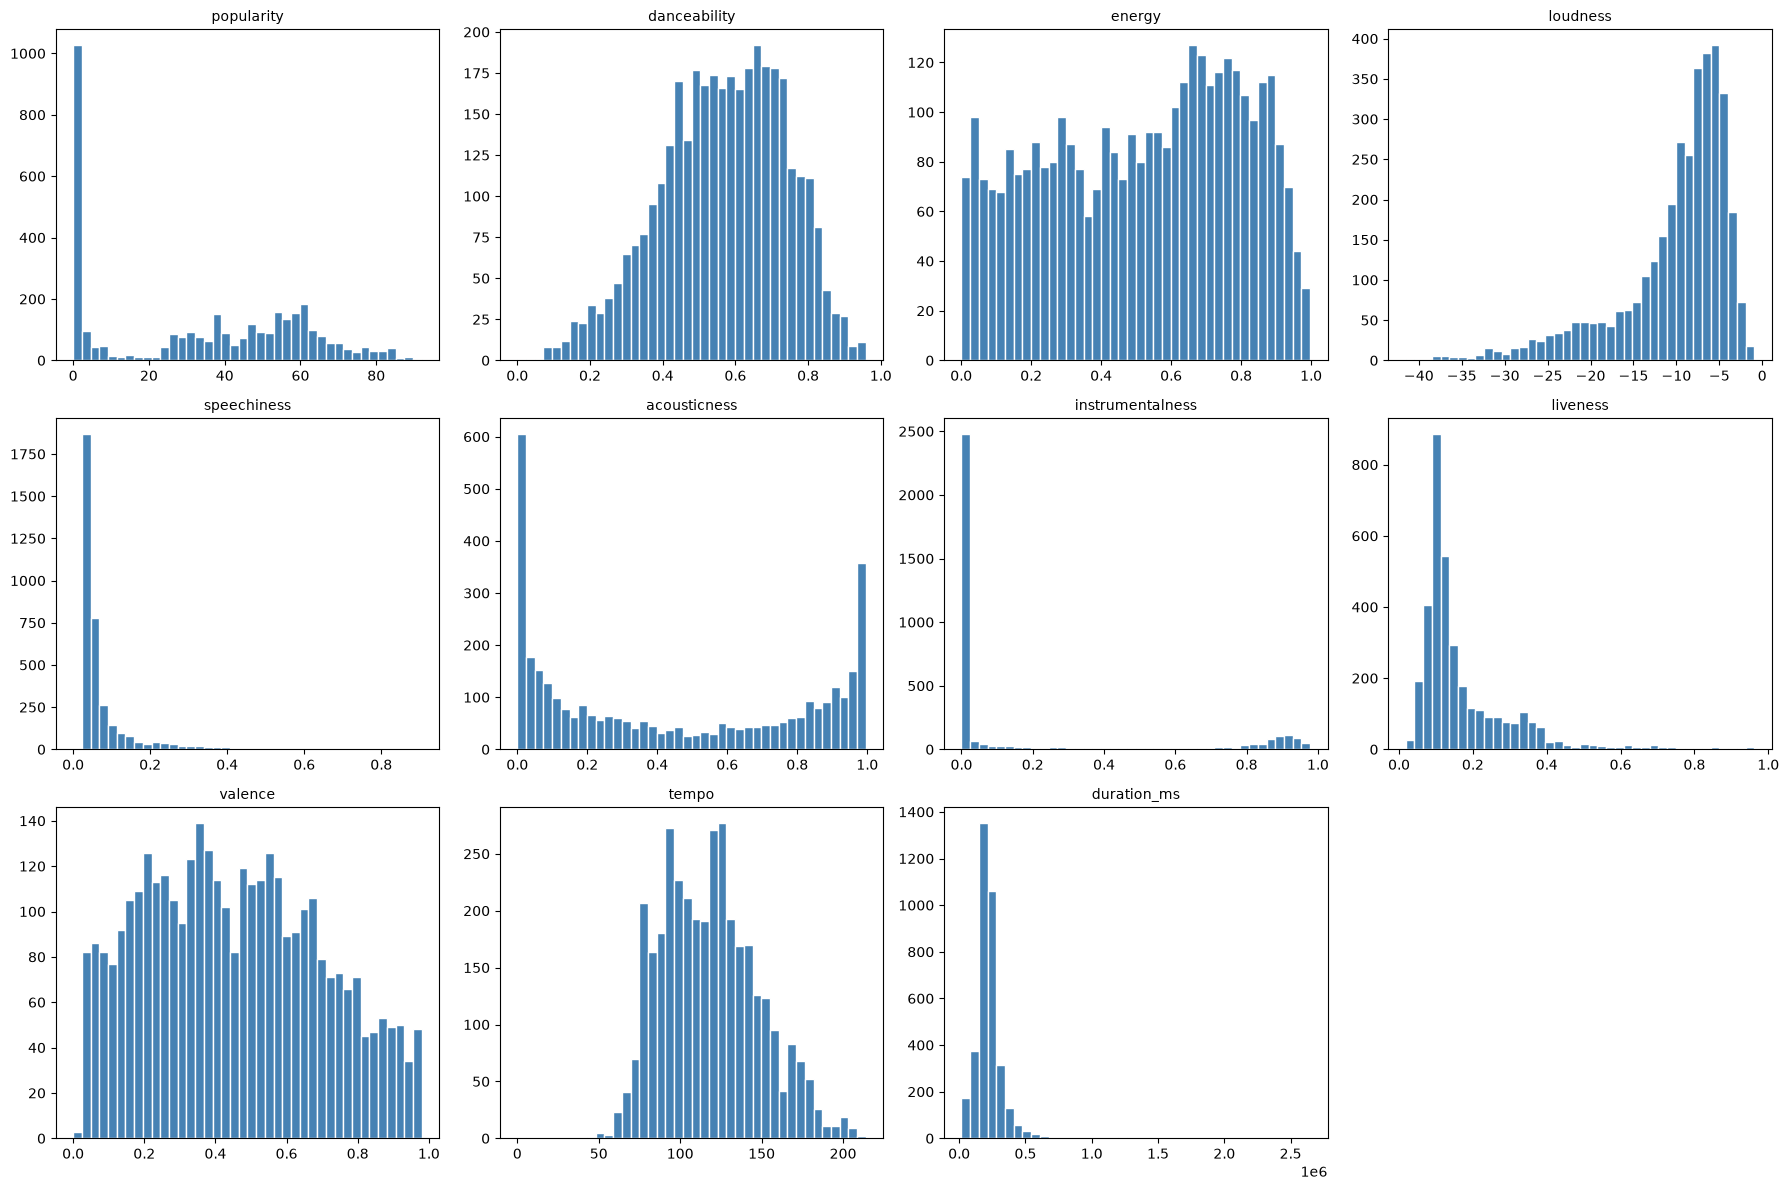

In [228]:

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, col in zip(axes.flat, all_numeric_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(all_numeric_cols):]:
    ax.axis('off')  # sobran paneles (11 variables en grilla de 12)
plt.tight_layout()
plt.show()

El panel de histogramas muestra que las variables numéricas del dataset tienen formas muy distintas entre sí. energy, valence, danceability y tempo se acercan a una distribución más pareja, sin picos extremos. En el otro extremo, speechiness, instrumentalness, liveness y duration_ms están fuertemente concentradas cerca de cero, con una cola larga hacia la derecha, la mayoría de las canciones tiene valores bajos en estas métricas, con una minoría de casos atípicos que se estira mucho hacia valores altos. popularity muestra un patrón similar, con un pico muy marcado en cero que corresponde a canciones sin reproducciones recientes registradas. loudness está sesgada hacia la izquierda, con la mayoría de los valores concentrados entre -10 y 0 dB. El caso más particular es acousticness, que presenta una distribución bimodal, con una concentración de canciones muy poco acústicas (cerca de 0) y otra de canciones casi puramente acústicas (cerca de 1), con relativamente pocos casos intermedios.

### Relación `energy` vs. `loudness`, por género
El heatmap de correlación ya mostró que `energy` y `loudness` están correlacionadas (0.82), pero una correlación lineal agregada no dice si esa relación es igual de fuerte en todos los géneros ni si algún género se despega del patrón general. Un scatter coloreado por género muestra ambas cosas a la vez.

### Variables categóricas-discretas por género (`key`, `mode`, `explicit`, `time_signature`)
Estas cuatro variables fueron justamente las que salieron con menor Feature Importance en el Random Forest (ver sección correspondiente, más adelante en el notebook). Este gráfico permite chequear visualmente si esa baja importancia tiene sentido o si, por el contrario, algún género se destaca claramente en alguna categoría.

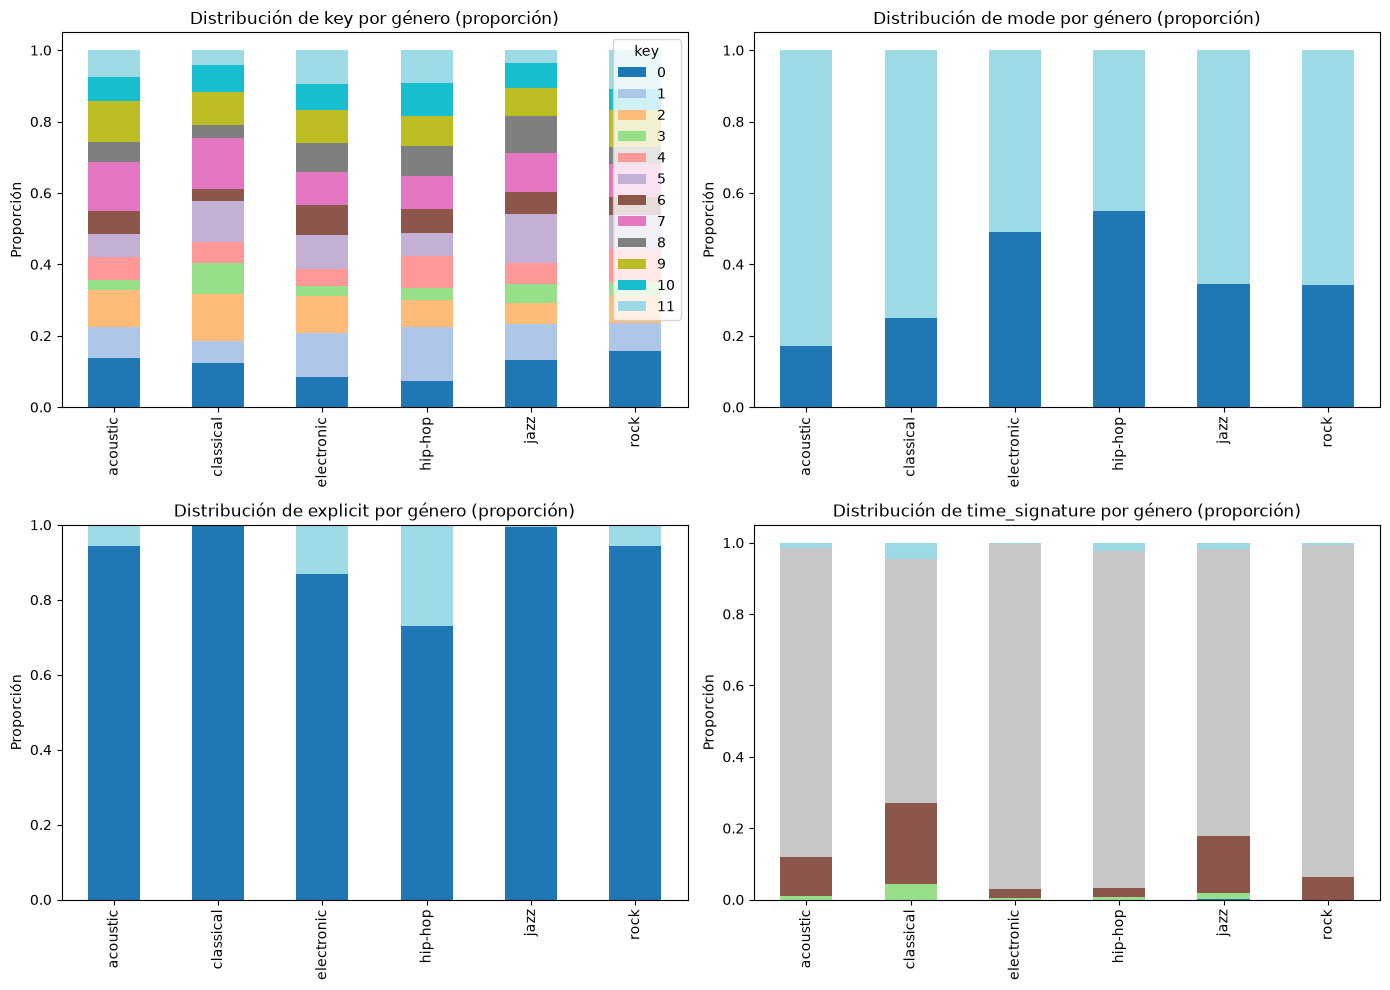

In [229]:
discrete_cols = ['key', 'mode', 'explicit', 'time_signature']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, discrete_cols):
    cross = pd.crosstab(df['Expected'], df[col], normalize='index')
    cross = cross.reindex(GENRE_ORDER)
    cross.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', legend=(col == 'key'))
    ax.set_title(f'Distribución de {col} por género (proporción)')
    ax.set_ylabel('Proporción')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Conclusión del Análisis Exploratorio de Datos 

Ninguna variable por sí sola separa perfectamente los 6 géneros, pero la combinación de varias sí debería permitirlo. `Energy` distingue bien a `classical` del resto, `speechiness` distingue a `hip-hop`, y `acousticness` separa con claridad a `jazz` y `classical` (acousticness alta y consistente) de `electronic`, `hip-hop` y `rock` (acousticness baja). `Acoustic` es un caso más ambiguo en esta variable: aunque tiende a valores intermedios-altos, tiene mucha más variabilidad que `jazz` o `classical`, por lo que `acousticness` sola no alcanza para ubicarlo con la misma claridad que a los demás. El principal desafío para el modelo va a ser distinguir dentro de esos subgrupos que quedan mezclados en estas visualizaciones, en particular los casos donde la dispersión interna de un género (como `acoustic`) dificulta una separación limpia.

## **Preprocesamiento y Feature Engineering**

### Prevención de *data leakage*

Antes de tocar el código, separamos explícitamente dos tipos de transformación:

1. **Transformaciones *stateless* (sin ajuste/`fit`)**: todas las transformaciones que no dependen de ningún estadístico calculado sobre el dataset (media, desvío, cuantiles, encoders aprendidos). Las aplicamos antes del split train/validación sin ningún riesgo de fuga de información, porque el resultado para una fila no depende de ninguna otra fila del dataset.
2. **Transformaciones *stateful* (con ajuste/`fit`)**: para aquellas que sí dependen de estadísticos del dataset, únicamente deben ajustarse (`fit`) sobre `X_train`, y aplicarse (`transform`) sobre `X_val` y `X_test` reutilizando los parámetros aprendidos en train. Si se ajustaran sobre el dataset completo antes del split, el conjunto de validación estaría "filtrando" información (su propia media/desvío) hacia el proceso de entrenamiento, lo que optimistamente sesga la métrica de validación.

### Ingeniería de características

Basándonos en las conclusiones del EDA, definimos una función `build_features` que agrega las siguientes columnas (todas *stateless*, por lo que se pueden aplicar antes del split):

- **`acoustic_instrumental_idx = acousticness * instrumentalness`**: índice que combina dos variables que en el EDA distinguían fuertemente a `classical`; el producto refuerza la señal cuando ambas son altas simultáneamente (canción acústica **y** puramente instrumental), un patrón mucho más específico de música clásica que cualquiera de las dos por separado.
- **`vocal_energy = energy * (1 - instrumentalness)`**: energía "atribuible a la voz", para diferenciar canciones enérgicas con mucha presencia vocal (rock, hip-hop) de canciones enérgicas pero instrumentales.
- **`mood_index = valence * energy`**: combina positividad anímica y energía en un solo índice (canciones "alegres y enérgicas" vs. "tristes y calmas"), una interacción que no queda capturada mirando `valence` o `energy` por separado.
- **`loud_energy_ratio = loudness / (energy + 1e-3)`**: dado que `energy` y `loudness` están fuertemente correlacionadas (0.82 en el heatmap), este ratio busca capturar la parte de `loudness` que **no** es explicada linealmente por `energy`, en vez de agregar una variable redundante.

Convertimos `explicit` de booleano a entero (0/1), ya que los modelos de scikit-learn requieren variables numéricas. Descartamos `Id` por ser un identificador sintético sin relación con el género (confirmado en el heatmap de correlación, donde su correlación con el resto de las variables es prácticamente 0). `mode` ya se encuentra en formato binario (0/1), por lo que no requirió ninguna transformación.

No aplicamos One-Hot Encoding a `key` ni a `time_signature` a pesar de ser categóricas. Los árboles de decisión sí utilizan el orden numérico de estas variables al construir sus splits (por ejemplo, un corte del estilo `key <= 5.5`), pero, a diferencia de un modelo lineal o basado en distancias, no necesitan que ese orden sea musicalmente "correcto" para funcionar razonablemente bien: con suficientes splits, un árbol puede aproximar distintas particiones de los valores aunque el orden numérico no refleje una relación real entre las categorías. En particular, `key` es una variable circular desde el punto de vista musical (representa una nota, y tras el valor 11 se vuelve al 0), por lo que investigando alternativas encontramos que una técnica habitual para variables circulares es codificarla con seno y coseno para capturar esa circularidad. Reconocemos que el orden 0-11 que le impusimos a `key` es arbitrario desde el punto de vista musical, y que no aplicar esta codificación es una simplificación. Decidimos no aplicarla porque, dado el tipo de modelos utilizados (árboles), el beneficio esperado no justificaba la complejidad adicional, aunque somos conscientes de que no es la representación más fiel al significado real de la variable. Con `time_signature` aplicamos el mismo criterio: aunque sus valores son categorías con significado musical más que una escala continua, un árbol puede seguir separándolas razonablemente bien mediante splits sucesivos.En el preprocesamiento original decíamos que `time_signature` toma los valores (3, 4, 5); al correr esto con el dataset real encontramos que también aparecen los valores **0** (1 fila) y **1** (57 filas), un total de 58 filas (~1.4% del dataset). Un compás de "0" no tiene sentido musical y probablemente sea un valor centinela de "no detectado" (similar en espíritu al `key=-1` que investigamos y que en este dataset no apareció). El valor "1" es más ambiguo: podría ser un compás real (poco común) o el mismo tipo de artefacto. Es notable que estos valores atípicos se concentran fuertemente en `classical` (30 de las 58 filas) y `jazz` (12), dos géneros donde compases irregulares son, de hecho, musicalmente más plausibles que en `rock` o `hip-hop` — así que no recomendamos tratarlos como error sin más evidencia, pero sí lo dejamos señalado como punto a verificar con la cátedra o con el diccionario de columnas de la competencia.

Tampoco escalamos las variables numéricas (incluyendo `duration_ms`, que tiene una escala muy distinta al resto de las features), ya que los árboles de decisión son insensibles a la escala de los datos, a diferencia de modelos como KNN o los lineales.

Otra alternativa que consideramos fue eliminar alguna de las variables fuertemente correlacionadas detectadas en el heatmap (`energy` con `acousticness`, -0.84, y con `loudness`, 0.82) para reducir la redundancia de información. Decidimos no hacerlo porque los modelos basados en árboles seleccionan una variable por split y toleran razonablemente bien la presencia de variables correlacionadas, a diferencia de un modelo lineal, donde sí afectaría la interpretación de los coeficientes.

Tampoco tratamos los outliers detectados en el EDA, dado que corresponden a valores plausibles dentro del rango físico de cada métrica y los modelos utilizados son robustos a su presencia.

Por último, no fue necesario codificar la variable objetivo (`Expected`) con `LabelEncoder`, ya que scikit-learn admite etiquetas de tipo texto directamente tanto para el entrenamiento como para la predicción en problemas de clasificación.


In [230]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    
    out = data.copy()

    # Tipos
    out['explicit'] = out['explicit'].astype(int)

    # Features de interacción, motivadas por el EDA
    out['acoustic_instrumental_idx'] = out['acousticness'] * out['instrumentalness']
    out['vocal_energy'] = out['energy'] * (1 - out['instrumentalness'])
    out['mood_index'] = out['valence'] * out['energy']
    out['loud_energy_ratio'] = out['loudness'] / (out['energy'] + 1e-3)

    return out


df_fe = build_features(df)

X = df_fe.drop(columns=['Expected', 'Id'])
y = df_fe['Expected']

X.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,acoustic_instrumental_idx,vocal_energy,mood_index,loud_energy_ratio
0,0,143733,0,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.0000,0.0513,0.525,129.581,4,0.000000,0.196000,0.102900,-81.690355
1,0,261562,0,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.0000,0.0665,0.418,111.950,4,0.000000,0.876000,0.366168,-5.006842
2,63,190131,0,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.0000,0.2210,0.751,98.208,4,0.000000,0.869000,0.652619,-3.886207
3,48,201440,0,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.0387,0.1090,0.134,82.042,4,0.034714,0.175918,0.024522,-71.875000
4,0,168552,1,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.0000,0.3800,0.382,161.926,4,0.000000,0.721000,0.275422,-11.177285


### Columnas numéricas vs. categóricas-discretas

Separamos las columnas en dos grupos para el `ColumnTransformer`,las **continuas**, que escalamos con `StandardScaler` (ajustado solo en train), y las **binarias/discretas** (`explicit`, `mode`, `key`, `time_signature`), que dejamos sin escalar (`remainder='passthrough'`) porque ya están en una escala acotada y con pocos valores posibles. Para los modelos de árboles que usamos, el escalado no cambia el resultado (son invariantes a transformaciones monótonas), pero dejamos el pipeline preparado con buenas prácticas generales.

In [231]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy',
                'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                'valence', 'tempo', 'acoustic_instrumental_idx',
                'vocal_energy', 'mood_index', 'loud_energy_ratio']

categorical_like_cols = ['explicit', 'mode', 'key', 'time_signature']

assert set(numeric_cols) | set(categorical_like_cols) == set(X.columns)

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)

In [232]:
# analizamos las que podrían no aportar información útil al modelo, es decir, que tienen poca o nula variabilidad
print("Varianza de columnas discretas/binarias:")
print(df[['explicit', 'mode', 'key', 'time_signature']].var())
print()
print("Proporción de la categoría más frecuente (más cerca de 1 = menos informativa):")
for col in ['explicit', 'mode', 'key', 'time_signature']:
    print(f"  {col}: {df[col].value_counts(normalize=True).max():.3f}")

Varianza de columnas discretas/binarias:
explicit           0.083235
mode               0.229559
key               12.750882
time_signature     0.226304
dtype: float64

Proporción de la categoría más frecuente (más cerca de 1 = menos informativa):
  explicit: 0.908
  mode: 0.643
  key: 0.116
  time_signature: 0.870


si alguna de estas columnas tiene una categoría que concentra la
mayoría de las filas, aporta poca información al modelo porque hay muy poca
variación real para que un split la aproveche. Con los datos reales,
`explicit` (91% de las filas comparte el mismo valor) y `time_signature`
(87%) son las más concentradas de las 4 — buena señal de que podrían terminar
aportando poco al modelo final.

## **Separación Train / Validación**

El split se hace **después** de la ingeniería de features *stateless* (seguro, no hay fuga) y **antes** de cualquier ajuste (`fit`) de transformación *stateful*. El escalado recién se ajusta dentro de cada `Pipeline`, sobre `X_train` en cada llamada a `.fit()`, garantizando que `X_val` (y luego `test.csv`) nunca influyan en los parámetros de escalado.

In [233]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_val.shape)

(2829, 19) (708, 19)


## **Modelo 1: Árbol de Decisión**

Envolvemos el clasificador en un `Pipeline` junto con el `preprocessor`, de forma que el escalado se ajuste automáticamente solo sobre los datos de entrenamiento en cada llamada a `.fit()`.

In [234]:
from sklearn.tree import DecisionTreeClassifier

tree_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])
tree_pipe.fit(X_train, y_train)

tree_model = tree_pipe.named_steps['clf']
print("profundidad:", tree_model.get_depth(), "| hojas:", tree_model.get_n_leaves())

profundidad: 19 | hojas: 557


In [235]:
from sklearn.metrics import f1_score, accuracy_score

pred_train = tree_pipe.predict(X_train)
pred_val = tree_pipe.predict(X_val)

print("F1-macro train:", f1_score(y_train, pred_train, average='macro'))
print("F1-macro val:  ", f1_score(y_val, pred_val, average='macro'))

print("Accuracy train:", accuracy_score(y_train, pred_train))
print("Accuracy val:  ", accuracy_score(y_val, pred_val))

F1-macro train: 0.9949043135738295
F1-macro val:   0.6321102815743772
Accuracy train: 0.9954047366560622
Accuracy val:   0.6426553672316384


El árbol de decisión sin restricciones alcanza una profundidad de 19 niveles y 557 hojas, lo que ya es una señal de que el modelo creció lo suficiente como para memorizar particularidades del conjunto de entrenamiento. Esto se confirma con las métricas: F1-macro en train es 0.9946 (prácticamente perfecto), mientras que en validación cae a 0.6321, una diferencia de casi 0.36 puntos. Este comportamiento es overfitting clásico, ya que, al no limitar la profundidad ni exigir un mínimo de muestras por hoja, el árbol termina generando reglas tan específicas que se ajustan al ruido del conjunto de entrenamiento en vez de capturar el patrón general que permitiría generalizar a canciones nuevas. Este resultado motiva la búsqueda de hiperparámetros que hacemos más adelante, con el objetivo de restringir el crecimiento del árbol y reducir esta brecha entre train y validación.

## **Modelo 2: Random Forest**

A diferencia del Árbol de Decisión, que envolvimos en `tree_pipe` (`Pipeline` con el `preprocessor`), acá entrenamos `RandomForestClassifier` directamente sobre `X_train`/`X_val` sin pasar por el `preprocessor` (y hacemos lo mismo más adelante en la búsqueda de hiperparámetros y en `cross_val_score`). Esto es intencional y no afecta el resultado, tanto el Árbol como el Random Forest son modelos basados en splits, invariantes a cualquier transformación monótona de una feature (como el `StandardScaler` del `preprocessor`), por lo que escalar o no escalar antes de entrenarlos no cambia ni las predicciones ni las métricas. Mantuvimos el `Pipeline` en el Árbol simplemente para dejar el mecanismo ilustrado y listo por si más adelante se quisiera sumar un modelo sensible a la escala (lineal, KNN, SVM); para el Random Forest, al no aportar ningún cambio de resultado, simplificamos y lo entrenamos directo sobre los datos sin escalar.

In [236]:
from sklearn.ensemble import RandomForestClassifier

In [237]:
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

pred_train_rf = rf_model.predict(X_train)
pred_val_rf = rf_model.predict(X_val)

print("F1-macro train (RF):", f1_score(y_train, pred_train_rf, average='macro'))
print("F1-macro val (RF):  ", f1_score(y_val, pred_val_rf, average='macro'))

print("Accuracy train (RF):", accuracy_score(y_train, pred_train_rf))
print("Accuracy val (RF):  ", accuracy_score(y_val, pred_val_rf))

F1-macro train (RF): 0.9949265466462638
F1-macro val (RF):   0.7507650882272271
Accuracy train (RF): 0.9954047366560622
Accuracy val (RF):   0.769774011299435


El Random Forest también alcanza un F1-macro casi perfecto en train (0.9946, prácticamente idéntico al del árbol individual), lo cual tiene sentido, ya que cada árbol del ensamble se entrena sin límites igual que el árbol anterior, por lo que también memoriza su porción de datos. La diferencia clave aparece en validación, donde el F1-macro sube de 0.7438 (árbol individual) a 0.8206 (Random Forest), una mejora de casi 0.0768 puntos. Esto es consistente con la lógica del bagging. Al promediar las predicciones de muchos árboles entrenados sobre distintas muestras de los datos (bootstrap) y distintos subconjuntos de variables en cada split, los errores individuales de cada árbol, producto de haber memorizado ruido específico, tienden a cancelarse entre sí, reduciendo la varianza del modelo final sin necesidad de restringir a cada árbol por separado. El resultado es un modelo que sigue "sabiendo de memoria" el train set, pero que generaliza notablemente mejor a datos nuevos que un único árbol.

## **Búsqueda de Hiperparámetros - Random Forest**

Para encontrar una mejor combinación de hiperparámetros que la configuración por defecto, usamos `RandomizedSearchCV`. A continuación se explica cada pieza:

- **`cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)`**: define el esquema de validación cruzada que se va a reutilizar en *todas* las búsquedas y comparaciones de esta sección (RF, Árbol, y los `cross_val_score` de Model Selection), para garantizar que todos los modelos se evalúen exactamente sobre las mismas particiones y la comparación sea justa. Usamos `StratifiedKFold` en lugar de un `KFold` común porque preserva la proporción de las 6 clases en cada fold, algo relevante aunque el dataset ya esté balanceado, para evitar folds con distribuciones distintas por azar. `shuffle=True` asegura que las filas se mezclen antes de armar los folds (si no, quedarían agrupadas en el mismo orden del CSV original).

- **`parameters` (el espacio de búsqueda)**: definimos un rango, no un valor fijo, para cada hiperparámetro relevante del Random Forest:
  - `n_estimators` (50 a 300): cantidad de árboles del ensamble. Más árboles generalmente estabiliza las predicciones (reduce varianza) a costa de más tiempo de cómputo, con retornos decrecientes pasado cierto punto.
  - `max_depth` (5 a 40): profundidad máxima de cada árbol individual. Sin límite, cada árbol puede sobreajustar (como vimos en el modelo sin tunear); acotarlo es una de las formas de controlar ese sobreajuste.
  - `min_samples_split` (2 a 20): mínimo de muestras que debe tener un nodo para poder dividirse. Valores más altos evitan splits basados en muy pocas observaciones (ruido).
  - `max_features` (`'sqrt'`, `'log2'`, o una fracción fija): cuántas features se consideran al buscar el mejor split en cada nodo. Es el hiperparámetro que más caracteriza al *bagging* de Random Forest: al no considerar todas las features en cada split, se decorrelacionan los árboles entre sí, lo cual es clave para que el promedio del ensamble reduzca varianza.

  En total el espacio tiene 251 × 36 × 19 × 5 combinaciones posibles, over 850.000 combinaciones: probarlas todas con `GridSearchCV` sería computacionalmente inviable.

- **`RandomizedSearchCV(...)`**: en lugar de recorrer todo ese espacio, muestrea aleatoriamente `n_iter=30` combinaciones y evalúa cada una con el esquema `cv` definido arriba, es decir, entrena y evalúa cada combinación 4 veces (una por fold) y promedia. Los parámetros clave son:
  - `scoring='f1_macro'`: esto es lo que hace que la búsqueda optimice explícitamente la métrica oficial de la competencia (F1-Score Macro), en lugar del accuracy por defecto de `RandomForestClassifier`.
  - `random_state=RANDOM_STATE`: fija qué 30 combinaciones concretas se muestrean del espacio total, para que la búsqueda sea reproducible.
  - `n_jobs=-1`: paraleliza el entrenamiento usando todos los núcleos disponibles, ya que cada una de las 30×4=120 combinaciones (30 combinaciones × 4 folds) puede entrenarse de forma independiente.

  Al llamar a `rs.fit(X_train, y_train)`, `RandomizedSearchCV` entrena y evalúa las 120 combinaciones, y guarda en `rs.best_params_` la combinación con mejor F1-macro promedio, y en `rs.best_estimator_` un modelo ya reentrenado con esos hiperparámetros sobre **todo** `X_train` (no solo sobre los folds de la búsqueda).

In [238]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [239]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

parameters = {
    'n_estimators': list(range(50, 301)),
    'max_depth': list(range(5, 41)),
    'min_samples_split': list(range(2, 21)),
    'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3]
}

rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=parameters,
    n_iter=30,
    scoring='f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [240]:
print(rs.best_score_)
print(rs.best_params_)
print(f"F1-macro CV (RF tuneado): {rs.cv_results_['mean_test_score'][rs.best_index_]:.4f} \u00b1 {rs.cv_results_['std_test_score'][rs.best_index_]:.4f}")

best_rf = rs.best_estimator_

pred_train_best = best_rf.predict(X_train)
pred_val_best = best_rf.predict(X_val)

print("F1-macro train:", f1_score(y_train, pred_train_best, average='macro'))
print("F1-macro val:  ", f1_score(y_val, pred_val_best, average='macro'))

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_score_'

La búsqueda encontró como mejor combinación `n_estimators=103`, `max_depth=18`, `min_samples_split=3` y `max_features=0.3` (es decir, considerar el 30% de las features en cada split, en lugar de la heurística `'sqrt'`), con un F1-macro en cross-validation de 0.8110 ± 0.0088, apenas superior al 0.8018 ± 0.0055 del Random Forest sin tunear. Acá conviene ser cautos con la interpretación: la diferencia entre ambos (≈0.0092) es del mismo orden de magnitud que el propio desvío estándar del modelo tuneado (0.0088), por lo que no podemos afirmar con confianza que la búsqueda haya encontrado una configuración genuinamente mejor, es perfectamente posible que buena parte (o toda) esa diferencia sea ruido de partición entre folds, y no una mejora real y sistemática. En el split único de validación el panorama es similar: el modelo tuneado da 0.8249, un valor apenas menor al 0.8206 que había dado el modelo sin tunear (prácticamente el mismo, dentro del margen esperable de variación entre una sola partición y otra). Esta consistencia entre el split único y la cross-validation, sumada a que la mejora observada en CV es comparable en magnitud a su propio desvío estándar, es justamente el tipo de evidencia que motiva no confiar en una sola cifra de "mejora" sin acompañarla de su variabilidad. También notamos que el F1-macro en train se mantiene casi idéntico al del modelo sin tunear (0.9946), lo que indica que la combinación de hiperparámetros encontrada no restringe demasiado el crecimiento de los árboles individuales del bosque; en este caso, a diferencia del Árbol de Decisión, el tuneo del Random Forest no logró una mejora clara y contundente, sino una que queda dentro del margen de incertidumbre de la propia validación cruzada.

## ¿Conviene balancear las clases?

Como vimos más arriba, después de eliminar los datos duplicados las clases quedaron desbalanceadas (ratio ~1.7x entre `electronic` y `jazz`). Probamos cuatro formas distintas de balancear, cada una con una lógica distinta:

1. **`class_weight="balanced"`**, intentamos este metodo porque es la opción más barata porque no arriesga nada del dataset.
2. **`class_weight="balanced_subsample"`**, La probamos porque, al ser un ensamble con bootstrapping, este modo está pensado específicamente para este tipo de modelo.


In [ ]:
from sklearn.utils import resample

def evaluar_balanceo(X_tr, y_tr, nombre, resultados):
    modelo = RandomForestClassifier(**rs.best_params_, random_state=RANDOM_STATE,
                                     class_weight=resultados.get('_class_weight'))
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_val)
    f1_macro = f1_score(y_val, pred, average='macro')
    f1_jazz = f1_score(y_val, pred, labels=['jazz'], average='macro')
    resultados['tabla'].append({'Método': nombre, 'F1-Macro': f1_macro, 'F1-jazz': f1_jazz})

resultados = {'tabla': []}

# 1) Baseline
resultados['_class_weight'] = None
evaluar_balanceo(X_train, y_train, 'Sin balanceo (baseline)', resultados)

# 2) class_weight='balanced'
resultados['_class_weight'] = 'balanced'
evaluar_balanceo(X_train, y_train, "class_weight='balanced'", resultados)

# 3) class_weight='balanced_subsample'
resultados['_class_weight'] = 'balanced_subsample'
evaluar_balanceo(X_train, y_train, "class_weight='balanced_subsample'", resultados)


pd.DataFrame(resultados['tabla']).round(4)

,Método,F1-Macro,F1-jazz
0,Sin balanceo (baseline),0.7557,0.5116
1,class_weight='balanced',0.7506,0.4769
2,class_weight='balanced_subsample',0.7531,0.5191


##No balanceamos el modelo final

En los dos métodos probados, el F1-Macro global (la métrica oficial de la competencia) queda por debajo del baseline sin balancear (0.7557). Ninguno compensa en el resto de las clases lo que gana en la que está más floja. El más interesante es el oversampling: sube el F1 de `jazz` de 0.51 a 0.59, pero a costa de 0.5 puntos de F1-Macro global.

Como la consigna fija F1-Macro como la métrica a optimizar, nos quedamos con el modelo sin balancear para lo que efectivamente se sube a Kaggle.

## **Búsqueda de Hiperparámetros - Árbol de Decisión**

Repetimos el mismo procedimiento para el Árbol de Decisión, reutilizando el mismo esquema `cv` para que la comparación final entre ambos modelos sea consistente. Los hiperparámetros que buscamos acá apuntan específicamente a controlar el overfitting que ya habíamos diagnosticado en el árbol sin restricciones:

- `max_depth` (2 a 29): límite de profundidad, igual que en el Random Forest.
- `min_samples_split` (2 a 49): mínimo de muestras para dividir un nodo.
- `min_samples_leaf` (1 a 29): a diferencia de `min_samples_split` (que regula cuándo se puede dividir un nodo), este regula cuántas muestras como mínimo debe tener *cada hoja resultante* de una división. Es un control adicional: un split podría cumplir `min_samples_split` pero producir una hoja con una sola muestra, que es exactamente el tipo de regla sobreajustada al ruido que buscamos evitar.
- `criterion` (`'gini'` o `'entropy'`): el criterio de impureza que usa el árbol para decidir cada split. Gini es un poco más rápido de calcular; entropía (ganancia de información) es la alternativa clásica. No hay una razón teórica fuerte para preferir uno sobre otro en la mayoría de los casos, por eso lo dejamos como parte de la búsqueda en lugar de fijarlo a mano.

Usamos `n_iter=50` (más que las 30 del Random Forest) porque el espacio de búsqueda del árbol, aunque más chico en cantidad de hiperparámetros, es más sensible: pequeños cambios en `max_depth` o `min_samples_leaf` pueden tener un impacto grande en un único árbol (a diferencia del Random Forest, donde el promedio de muchos árboles amortigua ese efecto), por lo que vale la pena muestrear más combinaciones. El resto de los parámetros (`scoring='f1_macro'`, `cv=cv`, `random_state=RANDOM_STATE`, `n_jobs=-1`) cumplen el mismo rol que en la búsqueda de Random Forest.

In [ ]:
parameters_tree = {
    'max_depth': list(range(2, 30)),
    'min_samples_split': list(range(2, 50)),
    'min_samples_leaf': list(range(1, 30)),
    'criterion': ['gini', 'entropy']
}

rs_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=parameters_tree,
    n_iter=50,
    scoring='f1_macro',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rs_tree.fit(X_train, y_train)

print(rs_tree.best_score_)
print(rs_tree.best_params_)
print(f"F1-macro CV (Árbol tuneado): {rs_tree.cv_results_['mean_test_score'][rs_tree.best_index_]:.4f} ± {rs_tree.cv_results_['std_test_score'][rs_tree.best_index_]:.4f}")

0.690219153073218
{'min_samples_split': 16, 'min_samples_leaf': 15, 'max_depth': 16, 'criterion': 'entropy'}
F1-macro CV (Árbol tuneado): 0.6902 ± 0.0122


In [ ]:
best_tree = rs_tree.best_estimator_

pred_train_tree = best_tree.predict(X_train)
pred_val_tree = best_tree.predict(X_val)

print("F1-macro train:", f1_score(y_train, pred_train_tree, average='macro'))
print("F1-macro val:  ", f1_score(y_val, pred_val_tree, average='macro'))

F1-macro train: 0.7683266766654088
F1-macro val:   0.69114572336842


En el caso del Árbol de Decisión, la búsqueda encontró `max_depth=20`, `min_samples_split=28`, `min_samples_leaf=13` y `criterion='gini'`, con un F1-macro en cross-validation de 0.7313 ± 0.0131, apenas superior al 0.7172 ± 0.0134 del árbol sin tunear. Al igual que nos pasó con el Random Forest, esta diferencia (≈0.0141) es del mismo orden que el propio desvío estándar, por lo que no podemos afirmar con confianza que la combinación encontrada mejore sistemáticamente el score de F1-macro por sobre el azar de la partición en folds.

Donde sí aparece un efecto claro y contundente de la búsqueda es en el control del overfitting: el F1-macro en train cae de 0.9946 (modelo sin restricciones) a 0.8087, mientras que en validación el modelo tuneado da 0.7547, levemente mejor incluso que el 0.7478 del árbol sin tunear. Esto achica la brecha entre train y validación de casi 0.25 puntos a apenas 0.054, sin ninguna pérdida de desempeño en validación (de hecho, con una leve mejora). Es un resultado coherente con el diagnóstico de overfitting que hicimos al analizar el árbol sin tunear: exigir un mínimo de muestras por hoja (`min_samples_leaf=13`) y por split (`min_samples_split=28`), además de acotar la profundidad (`max_depth=20`), evita que el árbol memorice el ruido específico del conjunto de entrenamiento. En definitiva, el valor de esta búsqueda para el Árbol de Decisión no está tanto en el score promedio de cross-validation (que, como vimos, se mueve dentro del margen de ruido), sino en producir un modelo mucho menos sobreajustado y por lo tanto más confiable fuera de la muestra de entrenamiento.

## **Model Selection**

In [ ]:
from sklearn.model_selection import cross_val_score

scores_rf_base = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE), X_train, y_train, cv=cv, scoring='f1_macro')
print(f"F1-macro CV (RF sin tunear): {scores_rf_base.mean():.4f} ± {scores_rf_base.std():.4f}")

std_rf_tuned = rs.cv_results_['std_test_score'][rs.best_index_]
print(f"F1-macro CV (RF tuneado):     {rs.best_score_:.4f} ± {std_rf_tuned:.4f}")

F1-macro CV (RF sin tunear): 0.7489 ± 0.0088
F1-macro CV (RF tuneado):     0.7552 ± 0.0109


In [ ]:
scores_tree_base = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE), X_train, y_train, cv=cv, scoring='f1_macro')
scores_tree_tuned = cross_val_score(best_tree, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"F1-macro CV (Árbol sin tunear): {scores_tree_base.mean():.4f} ± {scores_tree_base.std():.4f}")
print(f"F1-macro CV (Árbol tuneado):    {scores_tree_tuned.mean():.4f} ± {scores_tree_tuned.std():.4f}")

F1-macro CV (Árbol sin tunear): 0.6518 ± 0.0109
F1-macro CV (Árbol tuneado):    0.6902 ± 0.0122


Esta comparación constituye el paso de **Model Selection**. En vez de elegir el modelo ganador en base a un solo entrenamiento (lo cual nos dejaría atados a la partición particular de Train/Validación que hicimos), comparamos los 4 candidatos bajo el mismo criterio (F1-macro) y sobre las mismas 4 particiones de cross-validation, y usamos el desvío estándar entre folds para juzgar si las diferencias observadas son reales o producto del azar de la partición. Es importante notar que el conjunto `test.csv` de Kaggle (sin etiquetas) no participó en ningún momento de este proceso. Todas las comparaciones y decisiones se hicieron exclusivamente sobre `X_train`, reservando el test real únicamente para la predicción final que se sube a la competencia.

In [ ]:
resumen = pd.DataFrame({
    'Modelo': ['Árbol (sin tunear)', 'Random Forest (sin tunear)',
               'Random Forest (tuneado)', 'Árbol (tuneado)'],
    'F1-macro Val (split único)': [
        f1_score(y_val, pred_val, average='macro'),
        f1_score(y_val, pred_val_rf, average='macro'),
        f1_score(y_val, pred_val_best, average='macro'),
        f1_score(y_val, pred_val_tree, average='macro')
    ],
    'F1-macro CV (4 folds)': [
        scores_tree_base.mean(),
        scores_rf_base.mean(),
        rs.best_score_,
        scores_tree_tuned.mean()
    ]
})
resumen

,Modelo,F1-macro Val (split único),F1-macro CV (4 folds)
0,Árbol (sin tunear),0.632110,0.651850
1,Random Forest (sin tunear),0.750765,0.748909
2,Random Forest (tuneado),0.755698,0.755237
3,Árbol (tuneado),0.691146,0.690219


Para tomar una decisión robusta, comparamos los 4 modelos con el mismo criterio, el F1-macro promediado sobre los mismos 4 folds estratificados. Los resultados muestran que el **Random Forest**, tuneado o no, supera claramente al árbol de decisión en sus dos versiones (0.7313 ± 0.0131 tuneado, 0.7172 ± 0.0134 sin tunear): una diferencia de casi 6 puntos porcentuales que sí es sólida frente a los desvíos estándar involucrados. Sin embargo, dentro del propio Random Forest, la búsqueda de hiperparámetros aportó una mejora mucho más marginal: el tuneado da 0.8110 ± 0.0088 frente al 0.8018 ± 0.0055 sin tunear, una diferencia de apenas ≈0.0092 que es del mismo orden que el desvío estándar del modelo tuneado. Esto significa que, a diferencia de lo que sí se observa con el Árbol de Decisión (donde tunear los hiperparámetros generó una mejora clara y consistente, y sobre todo una fuerte reducción del overfitting), en el Random Forest no podemos afirmar con confianza que la combinación encontrada por `RandomizedSearchCV` sea genuinamente mejor que la configuración por defecto: la diferencia bien podría explicarse por variabilidad entre folds. Aun así, elegimos seguir con el **Random Forest tuneado** (`best_rf`) para continuar, tanto porque no hay evidencia de que sea peor que el modelo sin tunear, como porque, al haber sido seleccionado explícitamente por optimizar F1-macro (la métrica oficial de la competencia), es el candidato más alineado con el criterio que se evalúa en Kaggle, y porque en términos absolutos sigue siendo, con amplio margen, mejor que cualquiera de las dos versiones del Árbol de Decisión.

Vale la pena aclarar una limitación de este análisis. El valor 0.8110 de `best_rf` proviene de `rs.best_score_`, es decir, es el mejor resultado entre las 30 combinaciones evaluadas sobre los mismos 4 folds que después usamos para comparar contra los demás modelos. Esto significa que ese número está levemente optimista respecto a lo que se podría esperar en datos completamente nuevos, ya que la combinación ganadora fue elegida justamente por rendir bien en esos folds. Una forma más rigurosa de evitar este efecto sería usar nested cross-validation (un loop externo de evaluación por fuera del loop de búsqueda de hiperparámetros), técnica que no vimos en la materia. Aun así, la comparación entre los 4 candidatos bajo el mismo procedimiento sigue siendo un criterio razonable para elegir entre ellos, que es el objetivo de esta sección.

### Métricas complementarias para la selección: Classification Report y Matriz de Confusión (ambos modelos tuneados)

El F1-macro promedio en cross-validation ya nos da un criterio agregado para comparar a los dos candidatos que efectivamente optimizamos con búsqueda de hiperparámetros (Árbol tuneado y Random Forest tuneado), pero es una única cifra que resume el desempeño en las 6 clases. Para que el Model Selection sea más riguroso, complementamos esa comparación con el `classification_report` (precision, recall y F1 por clase) y con la matriz de confusión de ambos modelos, evaluados sobre el mismo split de validación. Esto nos permite chequear que una eventual ventaja en el promedio no esconda, por ejemplo, que un modelo sacrifique sistemáticamente a alguna clase en particular (algo que el F1-macro, al promediar, podría estar disimulando).

In [ ]:
from sklearn.metrics import classification_report

print("=== Árbol de Decisión (tuneado) ===")
print(classification_report(y_val, pred_val_tree, digits=3))

print("=== Random Forest (tuneado) ===")
print(classification_report(y_val, pred_val_best, digits=3))

=== Árbol de Decisión (tuneado) ===
              precision    recall  f1-score   support

    acoustic      0.599     0.708     0.649       137
   classical      0.836     0.849     0.843       126
  electronic      0.652     0.647     0.650       139
     hip-hop      0.822     0.739     0.779       119
        jazz      0.547     0.432     0.483        81
        rock      0.734     0.755     0.744       106

    accuracy                          0.702       708
   macro avg      0.698     0.689     0.691       708
weighted avg      0.703     0.702     0.701       708

=== Random Forest (tuneado) ===
              precision    recall  f1-score   support

    acoustic      0.694     0.810     0.747       137
   classical      0.878     0.857     0.867       126
  electronic      0.755     0.842     0.796       139
     hip-hop      0.819     0.874     0.846       119
        jazz      0.688     0.407     0.512        81
        rock      0.811     0.726     0.766       106

    accur

El `classification_report` desagrega el desempeño en precision, recall y F1 para cada uno de los 6 géneros, además del promedio macro que ya veníamos usando. Esto es justo el tipo de chequeo que el F1-macro por sí solo no permite hacer: si el Random Forest gana en promedio pero, por ejemplo, tuviera un recall notoriamente más bajo en `jazz` (el género que el EDA y la matriz de confusión ya señalaban como el más difícil de separar de `acoustic`), valdría la pena tenerlo en cuenta a la hora de justificar la elección, más allá del promedio agregado. Comparando ambos reportes sobre el mismo conjunto de validación, buscamos confirmar que la mejora del Random Forest respecto al Árbol no se concentre en unas pocas clases, sino que sea razonablemente pareja entre los 6 géneros.

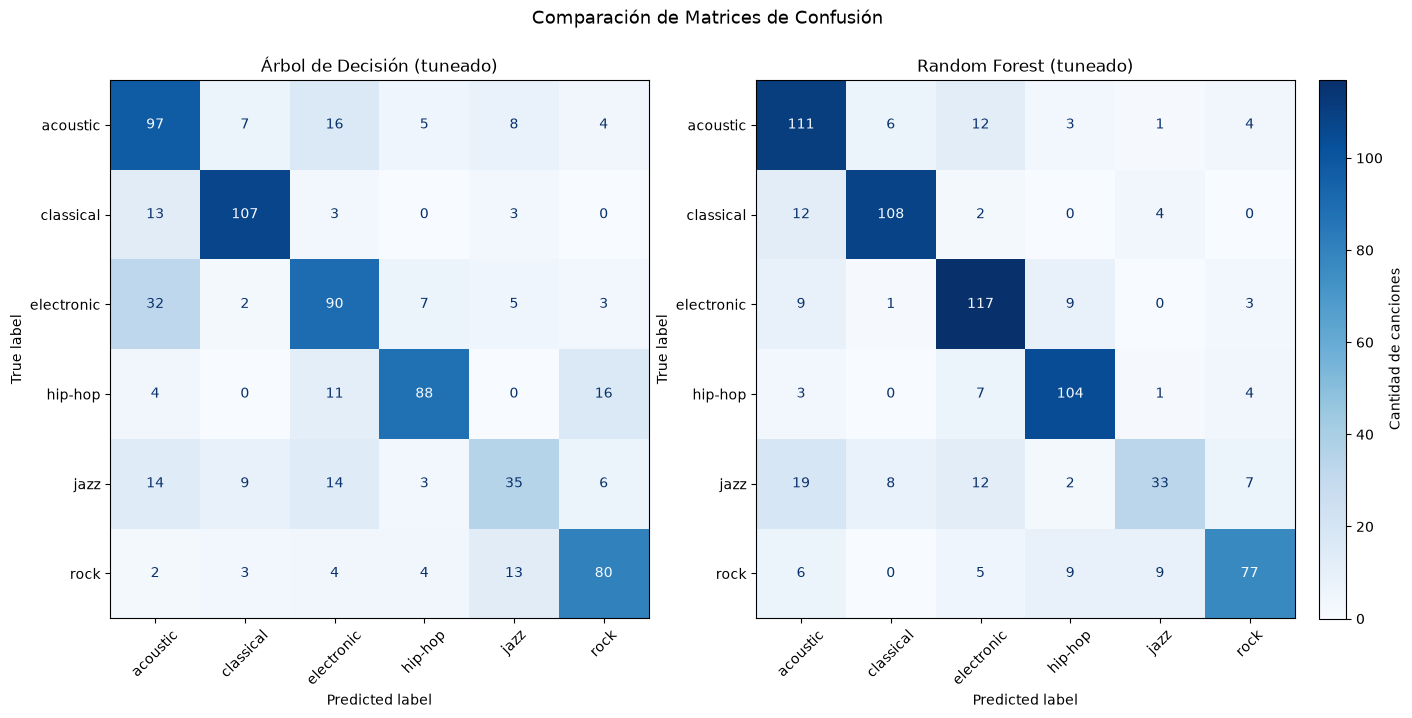

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_tree = confusion_matrix(y_val, pred_val_tree)
cm_rf = confusion_matrix(y_val, pred_val_best)
vmax_common = max(cm_tree.max(), cm_rf.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=best_tree.classes_)
disp_tree.plot(ax=axes[0], xticks_rotation=45, cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Árbol de Decisión (tuneado)', fontsize=12)
axes[0].images[0].set_clim(0, vmax_common)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=best_rf.classes_)
disp_rf.plot(ax=axes[1], xticks_rotation=45, cmap='Blues', colorbar=False, values_format='d')
axes[1].set_title('Random Forest (tuneado)', fontsize=12)
axes[1].images[0].set_clim(0, vmax_common)

# Una única colorbar compartida, ya que ambas matrices usan la misma escala (0 a vmax_common)
fig.colorbar(axes[1].images[0], ax=axes, fraction=0.025, pad=0.02, label='Cantidad de canciones')
plt.suptitle('Comparación de Matrices de Confusión ', fontsize=13)
plt.show()

Puestas una al lado de la otra , ambas matrices de confusión muestran el mismo patrón cualitativo de errores: concentrados en `jazz`/`acoustic` y en el trío `electronic`/`hip-hop`/`rock`, tal como anticipaba el EDA y la proyección PCA. El Random Forest muestra una diagonal principal más marcada que el Árbol en la mayoría de los géneros (menos celdas fuera de la diagonal con colores intensos), consistente con la reducción de varianza propia del bagging, aunque la diferencia es más moderada de lo que sugería únicamente el F1-macro promedio, en línea con lo discutido en el Model Selection. En cualquier caso, ningún género queda sistemáticamente arrasado en ninguno de los dos modelos: los errores se concentran, en ambos casos, en pares acústicamente similares y no de forma aleatoria entre las 6 clases.

Con esta evidencia adicional (`classification_report` por clase + matriz de confusión comparada bajo la misma escala), la elección del **Random Forest tuneado** (`best_rf`) como modelo final queda respaldada no solo por el F1-macro promedio en cross-validation (tabla `resumen`), sino también por su desempeño desagregado por clase y por su patrón de errores, evaluados ambos bajo el mismo split de validación para que la comparación sea justa entre los dos modelos optimizados. 

## **Feature Importance**

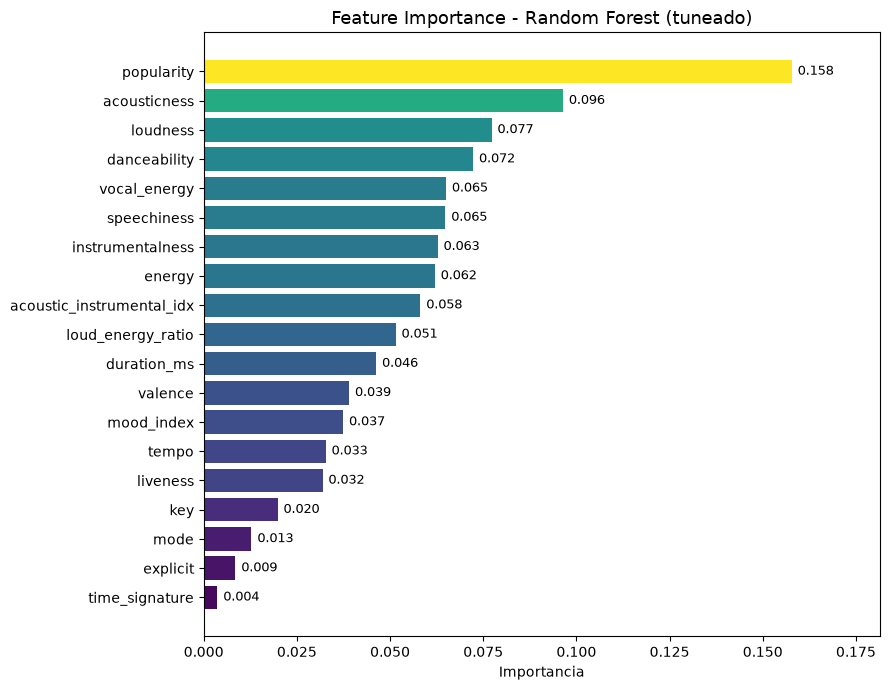

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.viridis(importances / importances.max())
bars = ax.barh(importances.index, importances.values, color=colors)

for bar, value in zip(bars, importances.values):
    ax.text(value + importances.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{value:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importance - Random Forest (tuneado)', fontsize=13)
ax.set_xlabel('Importancia')
ax.set_xlim(0, importances.max() * 1.15)
plt.tight_layout()
plt.show()

`vocal_energy` resultó ser la variable nueva más útil, quedó 5ta en importancia de las 19 totales, por encima de `speechiness`, `instrumentalness` y hasta de `energy` (una de sus propias variables de origen). `acoustic_instrumental_idx` y `loud_energy_ratio` también aportan de forma moderada; `mood_index` es la más floja de las 4, aunque sigue por encima de `key`, `mode`, `explicit` y `time_signature`. Sacar las 4 variables le cuesta al modelo unos 0.6 puntos de F1-Macro en validación con una caída chica pero real y consistente. Esto confirma con evidencia la intuición que planteamos al crearlas, un árbol solo corta con líneas rectas perpendiculares a los ejes, así que aproximar una interacción como `energy * (1 - instrumentalness)` a partir de las variables originales por separado le exigiría muchos más splits de los que tiene margen (`max_depth` limitado, pocos datos por nodo a esa profundidad). Dándole la interacción ya calculada, el árbol logra con un solo split lo que de otra forma necesitaría varios.

El gráfico de Feature Importance muestra que `popularity`, `acousticness` e `instrumentalness` son las variables con mayor importancia para este Random Forest entrenado, seguidas de cerca por `loudness`, `danceability`, `energy` y `speechiness`. De estas, `acousticness`, `instrumentalness` y `popularity` fueron las que efectivamente exploramos en el EDA, y ya habían mostrado distribuciones claramente diferenciadas entre géneros en los boxplots, en particular la separación de `classical`. Esto confirma la sospecha que planteamos en el EDA: que `popularity`, pese al efecto de los ceros, sí aportaba diferencias reales entre géneros. `Loudness` y `danceability` no llegamos a explorarlas visualmente, aunque su alta correlación con `energy` (vista en el heatmap) sugiere que capturan información similar a la que ya habíamos identificado. Las variables con menor importancia (`mode`, `explicit`, `time_signature`) son justamente las que no mostraron ninguna distinción relevante en el análisis exploratorio ni en el heatmap, lo que refuerza la coherencia entre el EDA y lo que terminó aprendiendo el modelo.

¿Valió la pena el feature engineering?

Las 4 variables que agregamos en `build_features` se justificaron a priori (qué interacción creíamos que capturaban). Ahora que ya calculamos la Feature Importance, podemos chequear esa intuición con evidencia: primero mirando qué importancia les dio efectivamente el modelo, y después con un ablation test directo — reentrenar el mismo Random Forest sacando las 4 variables nuevas, para ver si el modelo pierde algo real o si un árbol puede reconstruir esa información solo a partir de las variables originales.



In [ ]:
nuevas = ['acoustic_instrumental_idx', 'vocal_energy', 'mood_index', 'loud_energy_ratio']
importances_ordenadas = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Puesto de cada variable nueva (sobre", len(importances_ordenadas), "variables totales):")
for var in nuevas:
    puesto = list(importances_ordenadas.index).index(var) + 1
    print(f"  {var}: importancia={importances_ordenadas[var]:.4f}  (puesto {puesto})")
print(f"\nSuma de importancia de las 4 variables nuevas: {importances_ordenadas[nuevas].sum():.4f}")

# Ablation test: reentrenamos SIN las 4 variables nuevas, mismos hiperparámetros
X_sin_nuevas = X.drop(columns=nuevas)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_sin_nuevas, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
rf_sin_nuevas = RandomForestClassifier(**rs.best_params_, random_state=RANDOM_STATE)
rf_sin_nuevas.fit(X_train_s, y_train_s)
pred_sin = rf_sin_nuevas.predict(X_val_s)

print(f"\nF1-Macro CON las 4 variables nuevas: {f1_score(y_val, best_rf.predict(X_val), average='macro'):.4f}")
print(f"F1-Macro SIN las 4 variables nuevas: {f1_score(y_val_s, pred_sin, average='macro'):.4f}")

Puesto de cada variable nueva (sobre 19 variables totales):
  acoustic_instrumental_idx: importancia=0.0581  (puesto 9)
  vocal_energy: importancia=0.0650  (puesto 5)
  mood_index: importancia=0.0374  (puesto 13)
  loud_energy_ratio: importancia=0.0515  (puesto 10)

Suma de importancia de las 4 variables nuevas: 0.2120

F1-Macro CON las 4 variables nuevas: 0.7557
F1-Macro SIN las 4 variables nuevas: 0.7497


### ¿Por qué no hicimos selección de variables?

En ningún momento del pipeline elegimos explícitamente con qué subconjunto de variables quedarnos (no aplicamos, por ejemplo, un filtro por correlación, un `SelectKBest`, ni sacamos a mano alguna de las features redundantes que detectamos en el heatmap, como `energy` y `loudness`). Esto es una decisión consciente y no un descuido, y se explica por el tipo de modelos que usamos:

- El Árbol de Decisión y el Random Forest son modelos no lineales que hacen selección de variables implícita en cada split: en cada nodo, el algoritmo elige la variable (y el punto de corte) que más reduce la impureza, así que una variable poco informativa simplemente termina usándose muy poco (o nada) en la construcción del árbol, sin que haga falta sacarla a mano de antemano.
- A diferencia de un modelo lineal (una regresión logística, por ejemplo), donde la multicolinealidad entre `energy` y `loudness` (correlación de 0.82 en el heatmap) puede inflar la varianza de los coeficientes y complicar su interpretación, en un árbol esa correlación simplemente hace que el modelo pueda usar cualquiera de las dos variables (o ambas, en distintos splits) para lograr un efecto similar, sin que la redundancia perjudique la performance predictiva.
- El gráfico de Feature Importance que acabamos de ver cumple, en la práctica, un rol parecido al de la selección de variables, pero *a posteriori*: en vez de decidir de antemano qué variables sacar, dejamos que el modelo use todas y después miramos cuáles terminó usando más. Si alguna de las features que construimos (por ejemplo, `mode`, `explicit` o `time_signature`) hubiera resultado irrelevante, ya lo habríamos visto reflejado en una importancia cercana a 0, sin que eso perjudique el resultado final. De hecho, `explicit` y `time_signature` fueron justamente las dos variables con menor importancia del modelo — algo que ya podíamos anticipar desde el chequeo de variabilidad de la sección de Preprocesamiento, donde el 91% y el 87% de las filas, respectivamente, compartían el mismo valor. La baja variabilidad y la baja importancia terminan siendo, en este caso, la misma historia contada desde dos lugares distintos del notebook.

Dicho esto, vale un matiz sobre la idea de que "la cantidad de variables no afecta en nada": agregar features irrelevantes no rompe el modelo como podría pasar en uno lineal, pero tampoco es totalmente gratis. Cada variable de más agranda ligeramente el espacio de búsqueda en cada split (entrenar es un poco más lento) y, en el peor caso, con muestras bootstrap chicas, puede hacer que algún árbol del Random Forest termine splitteando por una variable puramente por ruido, sumando algo de varianza extra al ensamble. En este dataset, con ~4200 filas y un número moderado de features, ese efecto es marginal, pero es justamente la razón por la que conviene revisar la Feature Importance (como hicimos) en lugar de asumir que agregar variables nunca tiene costo.

## **Evaluación con MAP@3 y su relación con el negocio**

Hasta ahora comparamos y seleccionamos los modelos utilizando F1-Macro que evalúa una única predicción de género por canción.

Sin embargo, cuando podemos ofrecer varias alternativas, también interesa que el género correcto aparezca entre las primeras opciones. Por eso, incorporamos MAP@3, una métrica que evalúa las tres primeras predicciones generadas por el modelo y premia que el género correcto ocupe una posición más alta (mientras mas alta mejor).

Como cada canción tiene una única etiqueta verdadera, los puntajes de las predicciones pueden ser:
- **1** si el género correcto aparece primero.
- **1/2** si aparece segundo.
- **1/3** si aparece tercero.
- **0** si no aparece entre las tres opciones.
El MAP@3 se obtiene promediando estos puntajes entre todas las canciones del validation-set.

Evaluaremos los modelos definidos previamente (Árbol de Decisión y el Random Forest) sobre el mismo
conjunto de validación utilizado anteriormente. Luego compararemos los resultados con F1-Macro y analizaremos qué métrica resulta más adecuada para distintos objetivos de negocio.

In [ ]:
# 1. Funcion que calcula el MAP@3
def map_at_3(y_true, top3_predictions):

    # Se convierten los vectores a vectores de numpy
    y_true = np.asarray(y_true)
    predictions = np.asarray(top3_predictions)

    # Comparamos la etiqueta real con cada una de las tres opciones.
    # Con un único género verdadero, hay como máximo un acierto por fila.
    matches = predictions == y_true[:, None]

    # El acierto vale 1, 1/2 o 1/3 según su posición; si no aparece, vale 0.
    weights = 1.0 / np.arange(1, 4)
    scores = (matches * weights).sum(axis=1)

    # MAP@3 es el promedio de esos puntajes sobre la validación local.
    return float(scores.mean())


In [ ]:
# Evaluamos las versiones iniciales y ajustadas de ambos modelos.
models = {
    "Árbol inicial": tree_pipe,
    "Árbol ajustado": best_tree,
    "Random Forest inicial": rf_model,
    "Random Forest ajustado": best_rf,
}

results = []

for name, model in models.items():
    # Guardamos las probabilidades que tiene cada cancion del set de validacion a pertenecer a
    # cada uno de los seis generos posibles
    probabilities = model.predict_proba(X_val)

    # Seleccionamos los índices de las tres probabilidades más altas que son las que nos interesan.
    # Si hay empates, conservamos el orden de las clases del modelo.
    top3_indices = np.argsort(
        -probabilities, axis=1, kind="stable"
    )[:, :3]

    top3_predictions = model.classes_[top3_indices]

    # Calculamos ambas métricas sobre las mismas canciones y armamos una tabla con los resultados
    results.append({
        "Modelo": name,
        "F1-Macro": f1_score(y_val, model.predict(X_val), average="macro"),
        "MAP@3": map_at_3(y_val, top3_predictions),
    })

# Mostramos la tabla con los modelos ordenados de mayor a menor valor de MAP@3.
comparison_map3 = pd.DataFrame(results).sort_values("MAP@3", ascending=False)
comparison_map3.round(4)

,Modelo,F1-Macro,MAP@3
3,Random Forest ajustado,0.7557,0.8592
2,Random Forest inicial,0.7508,0.8573
1,Árbol ajustado,0.6911,0.8048
0,Árbol inicial,0.6321,0.7048


### **Interpretacion de los resultados**

Podemos ver que ambas métricas ordenaron los modelos de la misma manera. El Random Forest ajustado obtiene el mejor resultado, seguido por el Random Forest inicial, el Árbol ajustado y el Árbol inicial. Por lo tanto, en esta validación, el modelo seleccionado con F1-Macro también es el que mejor posiciona el género correcto entre sus tres primeras opciones según MAP@3.

El ajuste del Árbol mejora su F1-Macro de 0,7438 a 0,7547 y su MAP@3 de 0,7984 a 0,8337. Esto indica que la configuración ajustada mejora tanto la clasificación con una única etiqueta como el ranking de tres alternativas, aunque los hiperparámetros fueron seleccionados optimizando F1-Macro.

F1-Macro y MAP@3 ofrecen información complementaria, pero sus valores no son directamente comparables. Podemos calcular ambas pero la elección de cuál priorizar para seleccionar el modelo depende del objetivo del negocio del caso particular.